In [43]:
import sys
sys.path.append('../')
import scipy.io as sio
import mat73
import pandas as pd
import torch
import numpy as np
import torch.optim as optim
import torch.nn
import sklearn
import sklearn.metrics
import matplotlib.pyplot as plt
from alive_progress import alive_bar
from  utils.my_classes import dataset 
from torch.utils.data import DataLoader
import utils.DNN_functions as DNN_functions
import scipy
import random
import utils.AMSloss
from speechbrain.pretrained import SpeakerRecognition
import pickle
import os
from utils.my_classes import dataset
import utils.eval_metrics as eval_metrics
import copy
from speechbrain.pretrained import SpeakerRecognition

seed = 42  # You can choose any integer value as the seed
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
# Set seed for Python's random module
random.seed(seed)
# Set seed for NumPy
np.random.seed(seed)
# Set seed for PyTorch (CPU and GPU, if available)
if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
# Set deterministic flags for PyTorch (if available)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [44]:
#To get my GPU device - GTX 4070 :)
seed = 42  # You can choose any integer value as the seed
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');

if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.device(0))
    print(torch.cuda.get_device_name(0))
    print(device)

1
NVIDIA GeForce RTX 4070
cuda


# loading the embedding for CM System:

In [45]:
from ASV_utils.data_loading import *



models_folder = "Deep_Learning_Codes/best_models/fixed order/models/"

data_path_male = "Data/pmf_both/not_normalize/male/"

data_path_female = "Data/pmf_both/not_normalize/female/"

male_embedded_groups_1_1,male_embedded_groups_1_2,male_embedded_groups_1_3,male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id,male_chosen_labels_3_1_speaker_id,male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex  = load_data_male(data_path_male)

female_embedded_groups_1_1,female_embedded_groups_1_2,female_embedded_groups_1_3,female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex  = load_data_female(data_path_female)

# Pre Processing the channels And loading the Models - Male & Female:

In [46]:

import utils.my_functions as my_functions

columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)

female_embedded_groups_1_1 = female_embedded_groups_1_1[:,true_channels_indexes]
female_embedded_groups_1_2 = female_embedded_groups_1_2[:,true_channels_indexes]
female_embedded_groups_1_3 = female_embedded_groups_1_3[:,true_channels_indexes]

male_embedded_groups_1_1 = male_embedded_groups_1_1[:,true_channels_indexes]
male_embedded_groups_1_2 = male_embedded_groups_1_2[:,true_channels_indexes]
male_embedded_groups_1_3 = male_embedded_groups_1_3[:,true_channels_indexes]

In [47]:
from sklearn.preprocessing import StandardScaler
import re

your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract filter type, channel number, and distance metric
    match = re.search(r'filter-(gammatone|gammtone_inv)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        filter_type = match.group(1)  # 'gammatone' or 'gammtone_inv'
        channel = int(match.group(2))
        distance_metric = match.group(3)
        
        # Prioritize 'gammatone' before 'gammtone_inv'
        filter_priority = 0 if filter_type == 'gammatone' else 1

        # Sort by filter type, then by distance metric, and finally by channel
        return (filter_priority, distance_metrics.index(distance_metric), channel)

    else:
        # If the regex doesn't match, push the item to the end
        return (999, 999, 999)

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    
male_embedded_groups_1_1 = male_embedded_groups_1_1[:,list(index_mapping.keys())]
male_embedded_groups_1_2 = male_embedded_groups_1_2[:,list(index_mapping.keys())]
male_embedded_groups_1_3 = male_embedded_groups_1_3[:,list(index_mapping.keys())]

female_embedded_groups_1_1 = female_embedded_groups_1_1[:,list(index_mapping.keys())]
female_embedded_groups_1_2 = female_embedded_groups_1_2[:,list(index_mapping.keys())]
female_embedded_groups_1_3 = female_embedded_groups_1_3[:,list(index_mapping.keys())]



In [48]:
# define the subchannel model network
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss
import pickle
# define the subchannel model network
import torch.nn as nn
class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 

        
    def forward(self, x):
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        return x

# define the model network
class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,40)
        self.BN = nn.BatchNorm1d(40)
        self.fc = nn.Linear(40, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.loss = nn.BCEWithLogitsLoss()
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)



# Just for checking the model and see the number of parameters
num_SubChannelNetwork = 16
input_channel_size = 10
output_channel_size = 5
final_output_size = 1
model = []
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size)
model = model.to(device)
print(model)
n = DNN.count_parameters(model)
print("Number of parameters: %s" % n)
model = model.to(device) # send the model to the device
model = pickle.load(open(models_folder + "Male_best_model_8_6.pkl", 'rb'))

model.eval()

spoof_model_male = copy.deepcopy(model)

DNN(
  (SubChannelNetwork): ModuleList(
    (0-15): 16 x SubChannelNetwork(
      (input_layer): Linear(in_features=10, out_features=5, bias=True)
      (sigmoid): Sigmoid()
      (dropout): Dropout(p=0.2, inplace=False)
      (BN_4): BatchNorm1d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (fc_between_subnet): Linear(in_features=80, out_features=40, bias=True)
  (BN): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=40, out_features=1, bias=True)
  (sigmoid): Sigmoid()
  (droupout): Dropout(p=0.2, inplace=False)
  (loss): BCEWithLogitsLoss()
)
Number of parameters: 4401


In [49]:
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss
from utils.OCSoftmaxloss import OCSoftmax
import torch.nn as nn

class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 
   
    def forward(self, x):
        res = x
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        x = res + x 
        return x

class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size, r_real , r_fake,alpha):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,40)
        self.BN = nn.BatchNorm1d(40)
        self.fc = nn.Linear(40, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.r_real = r_real
        self.r_fake = r_fake
        self.alpha = alpha
        self.loss = OCSoftmax(feat_dim = final_output_size, r_real = self.r_real, r_fake = self.r_fake, alpha = self.alpha)
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

r_real = 0.5 
r_fake = 0.1
alpha = 20
# Example usage
num_SubChannelNetwork = 16
input_channel_size = 10
output_channel_size = 10
final_output_size = 16*3
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size,r_real = r_real , r_fake = r_fake,alpha = alpha)


model = model.to(device) # send the model to the device

model = pickle.load(open(models_folder + "Female_best_model_10_12.pkl", 'rb'))

model.eval()

spoof_model_female = copy.deepcopy(model)


In [50]:
scaler_male = StandardScaler(with_mean = True, with_std = True)
scaler_male.fit(male_embedded_groups_1_1)
mean_features = scaler_male.mean_
std_features = scaler_male.scale_
male_embedded_groups_1_1_norm = scaler_male.transform(male_embedded_groups_1_1)
male_embedded_groups_1_2_norm = scaler_male.transform(male_embedded_groups_1_2)
male_embedded_groups_1_3_norm = scaler_male.transform(male_embedded_groups_1_3)


scaler_female = StandardScaler(with_mean = True, with_std = True)
scaler_female.fit(female_embedded_groups_1_1)
mean_features = scaler_female.mean_
std_features = scaler_female.scale_
female_embedded_groups_1_1_norm = scaler_female.transform(female_embedded_groups_1_1)
female_embedded_groups_1_2_norm = scaler_female.transform(female_embedded_groups_1_2)
female_embedded_groups_1_3_norm = scaler_female.transform(female_embedded_groups_1_3)

In [51]:
embedded_groups_1_1_norm,embedded_groups_1_2_norm,embedded_groups_1_3_norm,chosen_labels_1_1_is_spoofed,chosen_labels_2_1_is_spoofed,chosen_labels_3_1_is_spoofed,chosen_labels_numeric_1_1,chosen_labels_numeric_2_1,chosen_labels_numeric_3_1,chosen_labels_1_1_attack_logical,chosen_labels_2_1_attack_logical,chosen_labels_3_1_attack_logical,chosen_labels_1_1_name,chosen_labels_2_1_name,chosen_labels_3_1_name,chosen_labels_1_1_speaker_id,chosen_labels_2_1_speaker_id,chosen_labels_3_1_speaker_id,chosen_labels_1_1_sex,chosen_labels_2_1_sex,chosen_labels_3_1_sex    =  concatenate_data(male_embedded_groups_1_1_norm,male_embedded_groups_1_2_norm,male_embedded_groups_1_3_norm,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id, male_chosen_labels_3_1_speaker_id,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_embedded_groups_1_1_norm,female_embedded_groups_1_2_norm,female_embedded_groups_1_3_norm,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex)


In [52]:
embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_    =  concatenate_data(male_embedded_groups_1_1,male_embedded_groups_1_2,male_embedded_groups_1_3,
                                                                                                                        male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,
                                                                                                                        male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,
                                                                                                                        male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,
                                                                                                                        male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,
                                                                                                                        male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id, male_chosen_labels_3_1_speaker_id,
                                                                                                                        male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex,
                                                                                                                        
                                                                                                                        female_embedded_groups_1_1,female_embedded_groups_1_2,female_embedded_groups_1_3,
                                                                                                                        female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,
                                                                                                                        female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,
                                                                                                                        female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,
                                                                                                                        female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,
                                                                                                                        female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,
                                                                                                                        female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex)
scaler_all = StandardScaler(with_mean = True, with_std = True)
scaler_all.fit(embedded_groups_1_1)
mean_features = scaler_female.mean_
std_features = scaler_female.scale_
embedded_groups_1_1_all = scaler_all.transform(embedded_groups_1_1)
embedded_groups_1_2_all = scaler_all.transform(embedded_groups_1_2)
embedded_groups_1_3_all = scaler_all.transform(embedded_groups_1_3)

In [53]:
train_dataset_all = dataset(data = embedded_groups_1_1_norm , is_spoofed = chosen_labels_1_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_1_1,
                        attack_logical = chosen_labels_1_1_attack_logical, name = chosen_labels_1_1_name , speaker_id = chosen_labels_1_1_speaker_id, sex = chosen_labels_1_1_sex ,data_transform = None , labels_transform = None,
                        data_for_gender_classification = None,data_without_separation = embedded_groups_1_1_all);

Dev_dataset_all = dataset(data = embedded_groups_1_2_norm , is_spoofed = chosen_labels_2_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_2_1,
                        attack_logical = chosen_labels_2_1_attack_logical, name = chosen_labels_2_1_name , speaker_id = chosen_labels_2_1_speaker_id, sex = chosen_labels_2_1_sex ,  data_transform = None , labels_transform = None,
                        data_for_gender_classification = None,data_without_separation = embedded_groups_1_2_all);


Eval_dataset_all = dataset(data = embedded_groups_1_3_norm , is_spoofed = chosen_labels_3_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_3_1,
                        attack_logical = chosen_labels_3_1_attack_logical, name = chosen_labels_3_1_name , speaker_id = chosen_labels_3_1_speaker_id, sex = chosen_labels_3_1_sex , data_transform = None , labels_transform = None,
                        data_for_gender_classification = None,data_without_separation = embedded_groups_1_3_all);


In [54]:
from ASV_utils.data_loading import *


models_folder = "ECAPA_TDNN/inference_models/models_both_not_normalize/"

data_path_male = "Data/male_vs_female_DB_models/16_bits/none/male/"

data_path_female = "Data/male_vs_female_DB_models/16_bits/none/female/"

g_male_embedded_groups_1_1,g_male_embedded_groups_1_2,g_male_embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_  = load_data_male(data_path_male)

g_female_embedded_groups_1_1,g_female_embedded_groups_1_2,g_female_embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_  = load_data_female(data_path_female)

embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_,_    =  concatenate_data(g_male_embedded_groups_1_1,g_male_embedded_groups_1_2,g_male_embedded_groups_1_3,
                                                                                                                    male_chosen_labels_1_1_is_spoofed,male_chosen_labels_2_1_is_spoofed,male_chosen_labels_3_1_is_spoofed,
                                                                                                                    male_chosen_labels_numeric_1_1,male_chosen_labels_numeric_2_1,male_chosen_labels_numeric_3_1,
                                                                                                                    male_chosen_labels_1_1_attack_logical,male_chosen_labels_2_1_attack_logical,male_chosen_labels_3_1_attack_logical,
                                                                                                                    male_chosen_labels_1_1_name,male_chosen_labels_2_1_name,male_chosen_labels_3_1_name,
                                                                                                                    male_chosen_labels_1_1_speaker_id,male_chosen_labels_2_1_speaker_id, male_chosen_labels_3_1_speaker_id,
                                                                                                                    male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex,
                                                                                                                    
                                                                                                                    g_female_embedded_groups_1_1,g_female_embedded_groups_1_2,g_female_embedded_groups_1_3,
                                                                                                                    female_chosen_labels_1_1_is_spoofed,female_chosen_labels_2_1_is_spoofed,female_chosen_labels_3_1_is_spoofed,
                                                                                                                    female_chosen_labels_numeric_1_1,female_chosen_labels_numeric_2_1,female_chosen_labels_numeric_3_1,
                                                                                                                    female_chosen_labels_1_1_attack_logical,female_chosen_labels_2_1_attack_logical,female_chosen_labels_3_1_attack_logical,
                                                                                                                    female_chosen_labels_1_1_name,female_chosen_labels_2_1_name,female_chosen_labels_3_1_name,
                                                                                                                    female_chosen_labels_1_1_speaker_id,female_chosen_labels_2_1_speaker_id,female_chosen_labels_3_1_speaker_id,
                                                                                                                    female_chosen_labels_1_1_sex,female_chosen_labels_2_1_sex,female_chosen_labels_3_1_sex)
chosen_labels_1_1_sex = np.array([elem[0] for elem in chosen_labels_1_1_sex])
                                 
chosen_labels_2_1_sex = np.array([elem[0] for elem in chosen_labels_2_1_sex])

chosen_labels_3_1_sex = np.array([elem[0] for elem in chosen_labels_3_1_sex])


In [55]:



import utils.my_functions as my_functions

columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)
'''
g_female_embedded_groups_1_1 = g_female_embedded_groups_1_1[:,true_channels_indexes]
g_female_embedded_groups_1_2 = g_female_embedded_groups_1_2[:,true_channels_indexes]
g_female_embedded_groups_1_3 = g_female_embedded_groups_1_3[:,true_channels_indexes]

g_male_embedded_groups_1_1 = g_male_embedded_groups_1_1[:,true_channels_indexes]
g_male_embedded_groups_1_2 = g_male_embedded_groups_1_2[:,true_channels_indexes]
g_male_embedded_groups_1_3 = g_male_embedded_groups_1_3[:,true_channels_indexes]
'''

embedded_groups_1_1 = embedded_groups_1_1[:,true_channels_indexes]
embedded_groups_1_2 = embedded_groups_1_2[:,true_channels_indexes]
embedded_groups_1_3 = embedded_groups_1_3[:,true_channels_indexes]

from sklearn.preprocessing import StandardScaler
import re

your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract filter type, channel number, and distance metric
    match = re.search(r'filter-(gammatone|gammtone_inv)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        filter_type = match.group(1)  # 'gammatone' or 'gammtone_inv'
        channel = int(match.group(2))
        distance_metric = match.group(3)
        
        # Prioritize 'gammatone' before 'gammtone_inv'
        filter_priority = 0 if filter_type == 'gammatone' else 1

        # Sort by filter type, then by distance metric, and finally by channel
        return (filter_priority, distance_metrics.index(distance_metric), channel)

    else:
        # If the regex doesn't match, push the item to the end
        return (999, 999, 999)

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    

embedded_groups_1_1 = embedded_groups_1_1[:,list(index_mapping.keys())]
embedded_groups_1_2 = embedded_groups_1_2[:,list(index_mapping.keys())]
embedded_groups_1_3 = embedded_groups_1_3[:,list(index_mapping.keys())]




In [56]:
scaler = StandardScaler(with_mean = True, with_std = True)
scaler.fit(embedded_groups_1_1)
mean_features = scaler.mean_
std_features = scaler.scale_

embedded_groups_1_1 = scaler.transform(embedded_groups_1_1)
embedded_groups_1_2 = scaler.transform(embedded_groups_1_2)
embedded_groups_1_3 = scaler.transform(embedded_groups_1_3)

train_dataset_all.data_for_gender_classification = embedded_groups_1_1
Dev_dataset_all.data_for_gender_classification   = embedded_groups_1_2
Eval_dataset_all.data_for_gender_classification  = embedded_groups_1_3


train_dataset_all.sex = pd.Series([elem[0] for elem in train_dataset_all.sex])
Dev_dataset_all.sex = pd.Series([elem[0] for elem in Dev_dataset_all.sex])
Eval_dataset_all.sex = pd.Series([elem[0] for elem in Eval_dataset_all.sex])

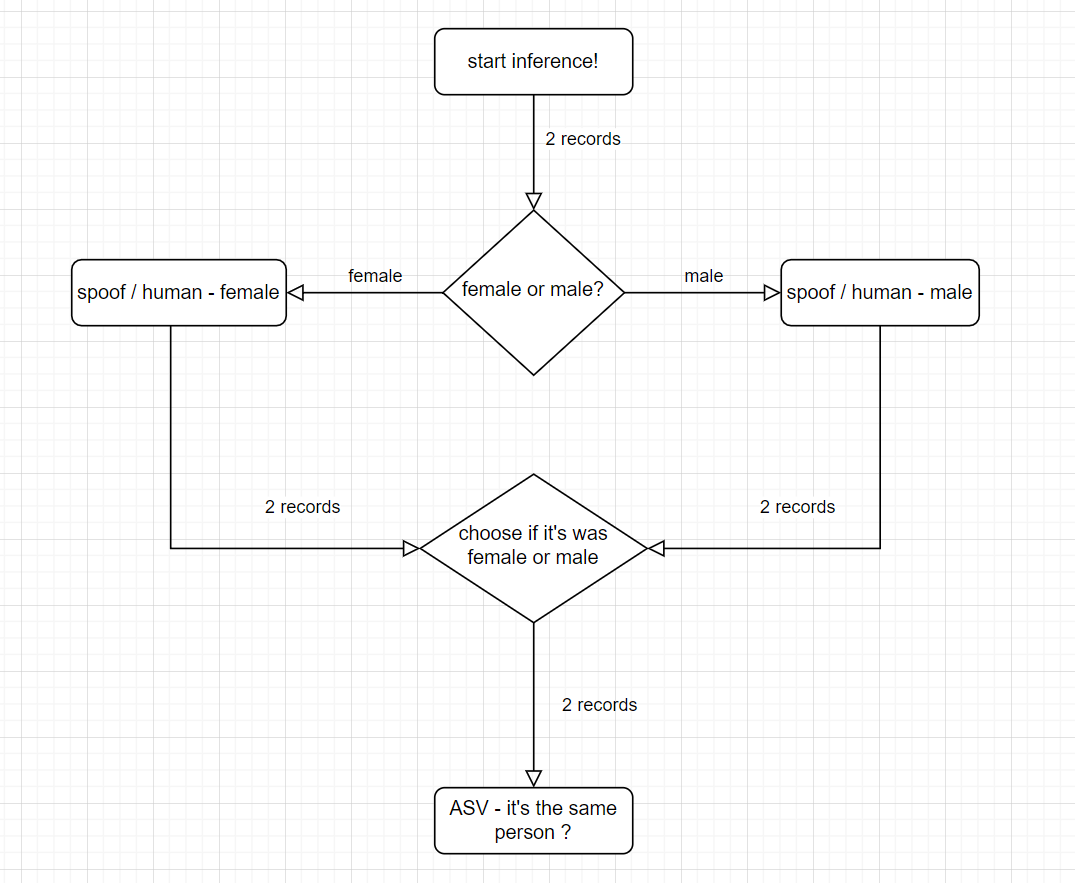

In [57]:
total_labels = torch.Tensor(Eval_dataset_all.is_spoofed[(Eval_dataset_all.sex == 'female').values].values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data[(Eval_dataset_all.sex == 'female').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    test_output = spoof_model_female(torch.Tensor(total_data).to(device))
    loss , test_score = spoof_model_female.loss(torch.Tensor(test_output).to(device),None)
    test_score = -1*test_score
    
test_score_total = test_score.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels,test_score_total) # compute equal error rate

print(f"\tTest EER: ({eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (0.10129787907565715%) 	Test Threshold: -0.8330833536418566


In [58]:
total_labels = torch.Tensor(Eval_dataset_all.is_spoofed[(Eval_dataset_all.sex == 'male').values].values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data[(Eval_dataset_all.sex == 'male').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    test_score = torch.sigmoid(spoof_model_male(torch.Tensor(total_data).to(device)))
    
test_score_total = test_score.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels,test_score_total) # compute equal error rate

print(f"\tTest EER: ({eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (0.08672798948696905%) 	Test Threshold: 0.04048307612539639


In [59]:
import torchaudio
from speechbrain.pretrained import EncoderClassifier

# load the model - the moodel that check if it's female or male
gender_models = "ML_codes/pmf_both_classification_male_vs_female/new_female_and_male/female_vs_male_histograms/normalize_all_best_fixed_order/"

with open(os.path.join(gender_models,"gender_XGB_model_both_norm_male_vs_female_db_models_5_fixed_order.pkl"), 'rb') as fp:
#with open(os.path.join(models_folder,"gender_XGB_model_both_norm_male_vs_female_db_models.pkl"), 'rb') as fp:
    gender_model = pickle.load(fp)
    
# load the model - the model that check if it's the sampe speaker or not
verification_model = SpeakerRecognition.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir='./ECAPA_TDNN/pretrained_models/spkrec-ecapa-voxceleb',run_opts={"device":"cuda"} )

classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir='./ECAPA_TDNN/pretrained_models/spkrec-ecapa-voxceleb',run_opts={"device":"cuda"})



c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\xgboost\core.py:160: UserWarning: [17:02:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


In [60]:
import pickle
from ASV_utils.ASV_my_functions import *
# Load the embeddings file:

with open('./ECAPA_TDNN/embeddings/dev_embedding_ecapa_voxceleb_flac.pkl', 'rb') as file:
    list_dev_files,embeddings_dev = pickle.load(file)
    list_dev_files = [name.rstrip('.flac') for name in list_dev_files]
    
with open('./ECAPA_TDNN/embeddings/eval_embedding_ecapa_voxceleb_flac.pkl', 'rb') as file:
    list_eval_files,embeddings_eval = pickle.load(file)
    list_eval_files = [name.rstrip('.flac') for name in list_eval_files]


embeddings_dev =[emb.cpu() for emb in embeddings_dev]
embeddings_dev = np.concatenate(embeddings_dev, axis=0)
embeddings_eval =[emb.cpu() for emb in embeddings_eval]
embeddings_eval = np.concatenate(embeddings_eval, axis=0)


path_enrollment_dev_female = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.female.trn.txt"

path_enrollment_dev_male = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.male.trn.txt"

path_enrollment_eval_female = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.female.trn.txt"

path_enrollment_eval_male = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.male.trn.txt"


enrollment_dev_female = make_enrollment(path_enrollment_dev_female,"female")

enrollment_dev_male = make_enrollment(path_enrollment_dev_male,"male")

enrollment_eval_female = make_enrollment(path_enrollment_eval_female,"female")

enrollment_eval_male = make_enrollment(path_enrollment_eval_male,"male")

enrollment_dev_female = extract_embeddings(list_dev_files,embeddings_dev,enrollment_dev_female)
list_dev_files,embeddings_dev = remove_enrollment_embeddings_from_embeddings_list(list_dev_files,embeddings_dev,enrollment_dev_female)

enrollment_dev_male = extract_embeddings(list_dev_files,embeddings_dev,enrollment_dev_male)
list_dev_files,embeddings_dev = remove_enrollment_embeddings_from_embeddings_list(list_dev_files,embeddings_dev,enrollment_dev_male)

enrollment_eval_female = extract_embeddings(list_eval_files,embeddings_eval,enrollment_eval_female)
list_eval_files,embeddings_eval = remove_enrollment_embeddings_from_embeddings_list(list_eval_files,embeddings_eval,enrollment_eval_female)

enrollment_eval_male = extract_embeddings(list_eval_files,embeddings_eval,enrollment_eval_male)
list_eval_files,embeddings_eval = remove_enrollment_embeddings_from_embeddings_list(list_eval_files,embeddings_eval,enrollment_eval_male)


In [61]:
path_trails_dev = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.gi.trl.txt"
path_trails_eval = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.gi.trl.txt"

def keys_to_values(key_list, input_dict):
    return [input_dict[key] for key in key_list if key in input_dict]

def read_trl_txt_file(path):
    speaker_id = []
    file_name = []
    spoof_label = []
    asv_label = []
    with open(path, 'r') as file:
        for line in file:
            parts = line.strip().split(' ')
            if len(parts) != 4:
                raise Exception("The line in the file is not in the right format")
            speaker_id.append(parts[0])
            file_name.append(parts[1])
            spoof_label.append(parts[2])
            asv_label.append(parts[3])
            
    return pd.Series(speaker_id), pd.Series(file_name), pd.Series(spoof_label),pd.Series(asv_label)

speaker_id_list_dev,file_name_according_speaker_id_dev , spoof_label_dev, asv_label_dev = read_trl_txt_file(path_trails_dev)

speaker_id_list_eval,file_name_according_speaker_id_eval , spoof_label_eval, asv_label_eval = read_trl_txt_file(path_trails_eval)
'''
speaker_id_dict_dev = dict(zip(file_name_according_speaker_id,speaker_id_list))

list_speaker_id_dev = keys_to_values(list_dev_files,speaker_id_dict_dev)


asv_label_dict_dev = dict(zip(file_name_according_speaker_id,asv_label_dev))

list_asv_label_dev = keys_to_values(list_dev_files,asv_label_dict_dev)





speaker_id_dict_eval = dict(zip(file_name_according_speaker_id,speaker_id_list))

list_speaker_id_eval = keys_to_values(list_eval_files,speaker_id_dict_eval)


asv_label_dict_eval = dict(zip(file_name_according_speaker_id,asv_label_eval))

list_asv_label_eval = keys_to_values(list_eval_files,asv_label_dict_eval)
'''


'\nspeaker_id_dict_dev = dict(zip(file_name_according_speaker_id,speaker_id_list))\n\nlist_speaker_id_dev = keys_to_values(list_dev_files,speaker_id_dict_dev)\n\n\nasv_label_dict_dev = dict(zip(file_name_according_speaker_id,asv_label_dev))\n\nlist_asv_label_dev = keys_to_values(list_dev_files,asv_label_dict_dev)\n\n\n\n\n\nspeaker_id_dict_eval = dict(zip(file_name_according_speaker_id,speaker_id_list))\n\nlist_speaker_id_eval = keys_to_values(list_eval_files,speaker_id_dict_eval)\n\n\nasv_label_dict_eval = dict(zip(file_name_according_speaker_id,asv_label_eval))\n\nlist_asv_label_eval = keys_to_values(list_eval_files,asv_label_dict_eval)\n'

In [62]:
def CM_inferernce_time_embeddings(data_for_gender_classification,data,gender_model,spoof_model_male,spoof_model_female,device,thr_gender,thr_spoof_male,thr_spoof_female,verbose = False):
    its_spoof_male = None
    its_spoof_female = None
    its_male = None
    with torch.no_grad():
        if gender_model.predict_proba([data_for_gender_classification])[:,1] > thr_gender: #need to normalize the data
            its_male = True
        else:
            its_male = False

        spoof_score_male = torch.sigmoid(spoof_model_male(torch.Tensor(data).unsqueeze(0)).cpu())
        spoof_score_male = spoof_score_male.item()
        if verbose:
            print(f"it's male spoof with score: {spoof_score_male}")
        if spoof_score_male <= thr_spoof_male:
            its_spoof_male = False
            if verbose:
                print("it's not spoof")
        else:
            its_spoof_male = True
            if verbose:
                print("it's spoof")
            
      
            
        spoof_model_female = spoof_model_female.to(device)
        test_output = spoof_model_female(torch.Tensor(data).unsqueeze(0).to(device))
        _ , spoof_score_female = spoof_model_female.loss(torch.Tensor(test_output).to(device),None) 
        spoof_score_female = -1*spoof_score_female.item()
        if verbose:
            print(f"it's female spoof with prob: {spoof_score_female}")
        if spoof_score_female <= thr_spoof_female:
            its_spoof_female = False
            if verbose:
                print("it's not spoof")
        else:
            its_spoof_female = True
            if verbose:
                print("it's spoof")
                
                    
       
        if its_spoof_female is None or its_spoof_male is None:
            raise Exception("its_spoof is None, need to check the inference function")
        
        if its_male is None:
            raise Exception("its_male is None, need to check the inference function")
        
        return its_male,its_spoof_male,its_spoof_female, spoof_score_male, spoof_score_female  


In [63]:
def inference_system_cm_asv_avg_score(spoof_labels,list_speaker_id,list_asv_label,txt_file_path,csv_file_path,thr_gender,thr_spoof_male,thr_spoof_female,enrollment_male, enrollment_female, list_files, data_set, gender_model, spoof_model_male, spoof_model_female, asv_model, device, verbose = False, verbose_txt = False,verbose_csv = False):
    '''
    This function is recognize the speaker in the data set, when the speaker don't say who he is, this task is like recognize the speaker. (Recognition task).
    '''
    
    # Initialize the dictionary with empty lists of data
    results = {  
        "file_name": [],
        "its_male": [],
        "its_male_ground_truth" : [],
        "its_spoof_male": [],
        "spoof_score_male": [],
        "its_spoof_female": [],
        "spoof_score_female": [],
        "spoof_ground_truth": [],
        "asv_score_male": [],
        "asv_score_female": [],
        "speaker_id_male": [],
        "speaker_id_female": [],
        "find_speaker_in_enroll_male": [],
        "find_speaker_in_enroll_female": [],
        "asv_label": [],
        "attack_type": [],
        "in_cm_protocol": []
    }
    
    if txt_file_path is None: # If the txt file path is None, then don't write to the txt file
        verbose_txt = False
        print("The output file path is None, so the results will not be saved in txt file")
    
    if csv_file_path is None: # If the csv file path is None, then don't write to the csv file
        verbose_csv = False
        print("The output file path is None, so the results will not be saved in csv file")

    if verbose_txt: # Open the txt file      
        txt_file = open(txt_file_path, 'w')
        
    if verbose_csv: # Open the csv file
        csv_file = open(csv_file_path, 'w', newline='')
        csv_writer = csv.writer(csv_file)
        csv_writer.writerow(results.keys())
        
    path_names = pd.Series(np.concatenate(data_set.name.values)) # Get the path names of the data set

    for  speaker_id,file_name,spoof_label,asv_label in tqdm.tqdm(zip(list_speaker_id,list_files,spoof_labels,list_asv_label), total=len(list_files)): # Iterate over the list of the files
    
        try:
            index_time_embedding = path_names.str.contains(file_name) # Get the index of the file in the data set
            
            if index_time_embedding.size == 0 or index_time_embedding is None: # If the index is empty, then raise an error
                raise ValueError(f"File {file_name} in list files, is not present in in list paths.")

            if verbose: # Print the file name and the index
                print(f"File {file_name} in list files, is at {path_names[index_time_embedding]} in list paths.")
                
        except ValueError: # If the index is empty, then raise an error
            print(f"File {file_name} in list files, is not present in in list paths.")

        time_embedding_norm = data_set.data[index_time_embedding].squeeze() # Get the time embedding of the file
        time_embedding_for_gender = data_set.data_for_gender_classification[index_time_embedding].squeeze()
        gender_embedding = data_set.sex.values[index_time_embedding][0]
        attack_type = data_set.attack_logical.values[index_time_embedding][0][0]
        speaker_id_cm_protocol = data_set.speaker_id.values[index_time_embedding][0]
        
        if str(speaker_id_cm_protocol) == speaker_id[-2:]:
            results["in_cm_protocol"].append(True)
        else:
            results["in_cm_protocol"].append(False)

        # this function calculate the CM inference of the time embedding 
        its_male,its_spoof_male,its_spoof_female, spoof_score_male, spoof_score_female  = CM_inferernce_time_embeddings(time_embedding_for_gender,time_embedding_norm, gender_model, spoof_model_male, spoof_model_female, device,thr_gender,thr_spoof_male,thr_spoof_female) # this function calculate

        if its_male is None: 
            raise Exception("its_male is None, need to check the inference function")

        if its_spoof_male is None or its_spoof_female is None:
            raise Exception("its_spoof is None, need to check the inference function")
        
        if spoof_score_male is None or spoof_score_female is None:
            raise Exception("spoof_score is None, need to check the inference function")
        
        if spoof_label == 'bonafide':
            spoof_label = 0
        else:
            spoof_label = 1
        
        if data_set.is_spoofed.values[index_time_embedding][0] != spoof_label:
            raise Exception("The spoof label is not equal to the ground truth spoof label")
        
        # Append the results to the data dictionary
        results["file_name"].append(file_name)
        results["its_male"].append(its_male)
        results["its_male_ground_truth"].append(gender_embedding)
        
        # for spoofing CM system
        results["its_spoof_male"].append(its_spoof_male)
        results["its_spoof_female"].append(its_spoof_female)
        results["spoof_ground_truth"].append(bool(data_set.is_spoofed.values[index_time_embedding][0]))
        results["spoof_score_male"].append(spoof_score_male)
        results["spoof_score_female"].append(spoof_score_female)
        
        # for ASV system
        results["asv_label"].append(asv_label)
        
        results["attack_type"].append(attack_type)
                
        signal, fs = torchaudio.load(str(path_names.values[index_time_embedding][0])) # load the signal from the path
        
        if fs != 16000: # if the sample rate is not 16000, then raise an error
            raise Exception("The sample rate is not 16000, need to check the inference function")
        
        embeddings = asv_model.encode_batch(signal)  # encode the signal
       
        embeddings = embeddings.cpu().numpy().squeeze(0) # convert the embeddings to numpy and send to cpu

        # initialize the helps variables
        find_speaker_in_enroll = False
      
        avg_score = 0
        list_scores_speaker = [];
        
        all_male_speakers_id = np.array(enrollment_male.get_all_speakers_id()) 

        for index_speaker,embedding_in_enroll_per_speaker in enumerate(np.array(enrollment_male.get_all_enrollment_embeddings())):
            for _,embedding_in_enroll in enumerate(embedding_in_enroll_per_speaker):
                if speaker_id == all_male_speakers_id[index_speaker]:
                    cos_score = cosine_similarity(embedding_in_enroll.squeeze().reshape(1, -1), embeddings.reshape(1, -1)) # calculate the cosine similarity between the embeddings
                    find_speaker_in_enroll = True
                    
                    if cos_score.shape != (1, 1): # if the cosine similarity is not scalar, then raise an error
                        raise Exception("cos_score shape is not (1,1) so is not scalar!, need to check the inference function")
                    
                    list_scores_speaker.append(cos_score.item()) 
        
        if len(list_scores_speaker) == 0:
            list_scores_speaker.append(0)  
            results["speaker_id_male"].append(None)      
        else:
            results["speaker_id_male"].append(speaker_id)   
                            
        avg_score = np.average(list_scores_speaker, axis = 0) # calculate the average score               
            

        results["asv_score_male"].append(avg_score) # the score of the current embedding with the enrollment embedding
               
        results["find_speaker_in_enroll_male"].append(find_speaker_in_enroll)
        
        
        find_speaker_in_enroll = False
     
        list_scores_speaker = [];
          
        all_female_speakers_id = np.array(enrollment_female.get_all_speakers_id()) 
        
        for index_speaker,embedding_in_enroll_per_speaker in enumerate(np.array(enrollment_female.get_all_enrollment_embeddings())):
            for _,embedding_in_enroll in enumerate(embedding_in_enroll_per_speaker):
                if speaker_id == all_female_speakers_id[index_speaker]:
                    cos_score = cosine_similarity(embedding_in_enroll.squeeze().reshape(1, -1), embeddings.reshape(1, -1)) # calculate the cosine similarity between the embeddings
                    find_speaker_in_enroll = True
                    
                    if cos_score.shape != (1, 1): # if the cosine similarity is not scalar, then raise an error
                        raise Exception("cos_score shape is not (1,1) so is not scalar!, need to check the inference function")
                    
                    list_scores_speaker.append(cos_score.item()) 
        
        
        if len(list_scores_speaker) == 0:
            list_scores_speaker.append(0)
            results["speaker_id_female"].append(None)      
        else:
            results["speaker_id_female"].append(speaker_id)  
                         
        avg_score = np.average(list_scores_speaker, axis = 0) # calculate the average score   
    
        
        results["asv_score_female"].append(avg_score) # the score of the current embedding with the enrollment embedding
        results["find_speaker_in_enroll_female"].append(find_speaker_in_enroll)
        
        
        if verbose: # Print the results
            print(f"file_name: {results['file_name'][-1]}, its_male: {results['its_male'][-1]}, its_spoof: {results['its_spoof'][-1]}, spoof_score: {results['spoof_score'][-1]}, spoof_ground_truth: {results['spoof_ground_truth'][-1]},asv_score: {results['asv_score'][-1]}, speaker_id: {results['speaker_id'][-1]} , pred_speaker_id: {results['pred_speaker_id'][-1]}, find_speaker_in_enroll: {results['find_speaker_in_enroll'][-1]} \n")
            
        if verbose_txt: # Write the results to the txt file
            txt_file.write(f"file_name: {results['file_name'][-1]}, its_male: {results['its_male'][-1]}, its_spoof: {results['its_spoof'][-1]}, spoof_score: {results['spoof_score'][-1]}, spoof_ground_truth: {results['spoof_ground_truth'][-1]},asv_score: {results['asv_score'][-1]}, speaker_id: {results['speaker_id'][-1]} , pred_speaker_id: {results['pred_speaker_id'][-1]}, find_speaker_in_enroll: {results['find_speaker_in_enroll'][-1]} \n")

        if verbose_csv: # Write the results to the csv file
            last_item = {key: list(values)[-1] for key, values in results.items()} # Get the last item of each list in the dictionary
            csv_writer.writerow(last_item.values()) # Write the last item to the csv file
        
    if verbose_txt: # Close the txt file
        txt_file.close()
        
    if verbose_csv:# Close the csv file
        csv_file.close() 
           
    results_df = pd.DataFrame(results)  # Return the DataFrame
    
    return results_df

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming list_tDCF_norm_male_dev, list_asv_score, and list_CM_thresholds_male_dev are defined
def heatmap_norm_tdcf(list_tDCF_norm,asv_scores,cm_thresholds,target_values,title,point_x_index=None, point_y_index=None,point_x_constrained=None,point_y_constrained=None,value = None):
    SIZE = 12
    
    plt.rc('legend', fontsize=SIZE)    # legend fontsize

    # Create a heatmap
    _, ax = plt.subplots(figsize=(10, 10))
    num_cm_to_plot = 10

    # Plot heatmap
    heatmap = ax.imshow(np.array(list_tDCF_norm).transpose(), cmap='viridis', aspect='auto', vmin=0, origin='lower', interpolation='none')

    # Set ticks and labels for x-axis (ASV scores)
    asv_indices = np.linspace(0, len(asv_scores) - 1, num_cm_to_plot, dtype=int)
    ax.set_xticks(asv_indices)
    ax.set_xticklabels(["{:.2f}".format(asv_scores[i]) for i in asv_indices])

    
    # Find the closest values
    
    cm_indices = [np.abs(cm_thresholds[0] - target).argmin() for target in target_values]
    
    
    #Set ticks and labels for y-axis (CM scores)
    ax.set_yticks(cm_indices)
    ax.set_yticklabels(["{:.3f}".format(cm_thresholds[0][i]) for i in cm_indices])
    
   
    '''
    defult_show = "female";
    if defult_show == "male":
        defult_indices = [cm_indices[0],cm_indices[-1]]
        ax.set_yticks(defult_indices)
        list_values = [0,1]
        #list_values = [cm_thresholds[0][0],cm_thresholds[0][-1]]
        ax.set_yticklabels(["{:.3f}".format(i) for i in list_values])
    else:
        defult_indices = [cm_indices[0],cm_indices[-1]]
        ax.set_yticks(defult_indices)
        list_values = [-1,1]
        #list_values = [cm_thresholds[0][0],cm_thresholds[0][-1]]
        ax.set_yticklabels(["{:.3f}".format(i) for i in list_values])
    '''
    # Add colorbar
    cbar = plt.colorbar(heatmap)
    cbar.set_label('norm T-DCF Values', rotation=270, labelpad=15)

    # Set axis labels
    ax.set_xlabel('ASV Thresholds')
    ax.set_ylabel('CM Thresholds')
    ax.set_title(title)
    
    asv_indices, cm_indices = np.meshgrid(
        np.arange(np.array(cm_thresholds).shape[1]),
        np.arange(np.array(asv_scores).shape[0])
    )
    contour = ax.contour(np.array(list_tDCF_norm).transpose(), levels=5, colors='white', origin='lower')
    plt.clabel(contour, inline=True, fontsize=10, fmt='%.2f', colors='white',zorder=1)
    
     # Plot the point if provided
    if point_x_index is not None and point_y_index is not None:
        ax.scatter(point_x_index, point_y_index,zorder=2, color='red', marker='X', label=f'Min norm t-DCF Optimal at ({asv_scores[point_x_index]:.2f},{cm_thresholds[point_x_index][point_y_index]:.2f}), Value: {list_tDCF_norm[point_x_index][point_y_index]:.4f}')
    
    
    if point_x_constrained is not None and point_y_constrained is not None:
        if value is None:
            ax.scatter(point_x_constrained, point_y_constrained, zorder=3,color='cyan', marker='X', label=f'Min norm t-DCF (fixed ASV Threshold) at ({asv_scores[point_x_constrained]:.2f},{cm_thresholds[point_x_constrained][point_y_constrained]:.2f}), Value: {list_tDCF_norm[point_x_constrained][point_y_constrained]:.4f}')
        else:
            ax.scatter(point_x_constrained, point_y_constrained, zorder=3,color='cyan', marker='X', label=f'Min norm t-DCF (fixed ASV Threshold) at ({asv_scores[point_x_constrained]:.2f},{cm_thresholds[point_x_constrained][point_y_constrained]:.2f}), Value: {value:.4f}')
    
    # Show the plot
    ax.legend(loc="lower right")
    plt.show()

In [65]:

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

def heatmap_norm_tdcf_3d(list_tDCF_norm, asv_scores, cm_thresholds, target_values, title,point_x_index=None, point_y_index=None):
    # Create a 3D plot
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Create meshgrid for x and y based on dimensions of the data
    
    
    
    asv_indices, cm_indices = np.meshgrid(
        np.arange(np.array(cm_thresholds).shape[1]),
        np.arange(np.array(asv_scores).shape[0])
    )

    # Plot the 3D surface
    surface = ax.plot_surface(asv_indices, cm_indices, np.array(list_tDCF_norm), cmap='viridis', vmin=0, vmax=1, rstride=1, cstride=1, linewidth=0, antialiased=False)

    # Set ticks and labels for x-axis (ASV scores)
    ax.set_xticks(np.arange(len(asv_scores)))
    ax.set_xticklabels(["{:.2f}".format(asv_scores[i]) for i in range(len(asv_scores))])

    # Set ticks and labels for y-axis (CM scores)
    ax.set_yticks(np.arange(len(target_values)))
    ax.set_yticklabels(["{:.3f}".format(cm_thresholds[0][i]) for i in range(len(target_values))])

    # Add colorbar
    cbar = fig.colorbar(surface, ax=ax, shrink=0.6)
    cbar.set_label('norm T-DCF Values', rotation=270, labelpad=15)

    # Set axis labels
    ax.set_xlabel('ASV Thresholds')
    ax.set_ylabel('CM Thresholds')
    ax.set_zlabel('norm T-DCF Values')
    ax.set_title(title)

    # Show the plot
    if point_x_index is not None and point_y_index is not None:
        ax.scatter(point_x_index, point_y_index, color='red', marker='X', label=f'min norm t-DCF Optimal in ({asv_scores[point_x_index]:.2f},{cm_thresholds[point_x_index][point_y_index]:.2f})')
        
    # Show the plot
    ax.legend()
    plt.show()

# Example usage:
# heatmap_norm_tdcf_3d(list_tDCF_norm_male_dev, list_asv_score, list_CM_thresholds_male_dev, target_values, "Title")
#list_asv_score = list(np.arange(0.01, 1.01, 0.01))
#nan_indices = np.where(np.isnan(list_tDCF_norm_male_dev))
#first_nan_row = nan_indices[0][0] if len(nan_indices[0]) > 0 else len(list_tDCF_norm_male_dev)

#list_tDCF_norm_male_dev_show = list_tDCF_norm_male_dev[0:first_nan_row]
#list_asv_score_show = list_asv_score[0:first_nan_row]

#heatmap_norm_tdcf_3d(list_tDCF_norm_male_dev_show,list_asv_score_show,list_tDCF_norm_male_dev_show, target_values = [0,0.01,0.02,0.03,0.1,0.2,0.41, 0.85,0.99,1],title ="Norm t-DCF - Male Gender on Development Set")


In [66]:
from sklearn.metrics.pairwise import cosine_similarity
import torchaudio
import tqdm
from ASV_utils.config_thr import pmf_both_thr_gender_val ,pmf_both_thr_spoof_val_male,pmf_both_thr_spoof_val_female
from ASV_utils.tdcf_functions import compute_t_dcf

txt_file_path = "output.txt"
csv_file_path = "output.csv"
enrollment_male = enrollment_dev_male
enrollment_female = enrollment_dev_female
list_files = file_name_according_speaker_id_dev
data_set = Dev_dataset_all
asv_model = classifier
spoof_labels = spoof_label_dev
list_speaker_id = speaker_id_list_dev
list_asv_label = asv_label_dev

#results = inference_system_cm_asv_avg_score(spoof_labels,list_speaker_id,list_asv_label,txt_file_path,csv_file_path,pmf_both_thr_gender_val,pmf_both_thr_spoof_val_male,pmf_both_thr_spoof_val_female,enrollment_male, enrollment_female, list_files, data_set, gender_model, spoof_model_male, spoof_model_female, asv_model, device, verbose = False, verbose_txt = False,verbose_csv = False)

In [67]:
from ASV_utils.tdcf_functions import compute_t_dcf
import pickle
results = pickle.load(open("./dcf_and_tdcf\dcf_avg_score/pmf_both_tdcf/asv_protocol/objects_asv_and_cm_time_embeddings_avg_score_both_asv_protocol.pkl", 'rb'))

In [68]:

import pickle

#with open('objects_asv_and_cm_time_embeddings_avg_score_both_asv_protocol.pkl', 'wb') as f:
#    pickle.dump(results,f)


# Male - DEV:

### with labels of gender:

In [69]:
labels_dev_male = torch.Tensor(Dev_dataset_all.is_spoofed[(Dev_dataset_all.sex == 'male').values].values).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data[(Dev_dataset_all.sex == 'male').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    score_dev_male = torch.sigmoid(spoof_model_male(torch.Tensor(total_data).to(device)))
    
score_dev_male = score_dev_male.cpu().numpy().copy()

dev_male_eer, _ = my_functions.compute_eer(labels_dev_male,score_dev_male) # compute equal error rate

print(f"\tDev male EER: ({100*dev_male_eer}%)")


	Dev male EER: (0.5546536796531659%)


In [70]:
#check what happen when the gender classification is mistake!!

bonafide_score_cm_male_dev = 1-score_dev_male[labels_dev_male == 0].flatten()
spoof_score_cm_male_dev = 1-score_dev_male[labels_dev_male == 1].flatten()
Prior_spoof = 0.05
target_scores_male_dev = results.loc[(results['asv_label'] ==  "target") & (results['its_male_ground_truth'] == 'male') ]["asv_score_male"].values
nontarget_scores_male_dev = results.loc[(results['asv_label'] == "nontarget") & (results['its_male_ground_truth'] == 'male') ]["asv_score_male"].values
spoof_scores_male_dev = results.loc[(results['asv_label'] ==  "spoof") & (results['its_male_ground_truth'] == 'male')]["asv_score_male"].values
list_asv_score = [0.261]
type = 'constrained'
list_tDCF_norm_male_dev ,list_CM_thresholds_male_dev,list_tDCF_male_dev = compute_t_dcf(bonafide_score_cm_male_dev,spoof_score_cm_male_dev,Prior_spoof,target_scores_male_dev,nontarget_scores_male_dev,spoof_scores_male_dev,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=868, Nspoof=7392] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  3.08466 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.261
the CM thresholds is:  [5.91026783e-04 1.59102678e-03 1.60676241e-03 ... 9.96470869e-01
 9.96529162e-01 9.97042716e-01]
the CM threshold min is: 0.7791557312011719

In [71]:
results

,file_name,its_male,its_male_ground_truth,its_spoof_male,spoof_score_male,its_spoof_female,spoof_score_female,spoof_ground_truth,asv_score_male,asv_score_female,speaker_id_male,speaker_id_female,find_speaker_in_enroll_male,find_speaker_in_enroll_female,asv_label,attack_type,in_cm_protocol
0,LA_D_4004968,True,male,False,0.006150,False,-0.912122,False,0.561741,0.000000,LA_0073,None,True,False,target,none,True
1,LA_D_6027798,True,male,False,0.006148,False,-0.935269,False,0.703008,0.000000,LA_0073,None,True,False,target,none,True
2,LA_D_3986002,True,male,False,0.007109,False,-0.915763,False,0.675328,0.000000,LA_0073,None,True,False,target,none,True
3,LA_D_9330492,True,male,False,0.005233,False,-0.903112,False,0.539661,0.000000,LA_0073,None,True,False,target,none,True
4,LA_D_1364611,True,male,False,0.007441,False,-0.909984,False,0.506510,0.000000,LA_0073,None,True,False,target,none,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29543,LA_D_6306347,False,female,True,0.959626,True,0.567938,True,0.000000,0.214340,None,LA_0069,False,True,spoof,A06,True
29544,LA_D_3133630,False,female,True,0.981835,True,0.644323,True,0.000000,0.155820,None,LA_0069,False,True,spoof,A05,True
29545,LA_D_9909170,False,female,True,0.979534,True,0.504778,True,0.000000,0.072316,None,LA_0069,False,True,spoof,A06,True
29546,LA_D_3790932,False,female,True,0.991858,True,0.779713,True,0.000000,0.182552,None,LA_0069,False,True,spoof,A05,True


In [72]:
# Sort target scores by index and extract the corresponding filenames
sorted_target_scores_male_dev = results.loc[
    (results['asv_label'] == "target")& (results['its_male_ground_truth'] == 'male'),
    ["asv_score_male", "file_name","asv_label","speaker_id_male","spoof_score_male"]
].sort_index()



# Sort nontarget scores by index and extract the corresponding filenames
sorted_nontarget_scores_male_dev = results.loc[
    (results['asv_label'] == "nontarget") & (results['its_male_ground_truth'] == 'male'),
    ["asv_score_male", "file_name","asv_label","speaker_id_male","spoof_score_male"]
].sort_index()



# Sort spoof scores by index and extract the corresponding filenames
sorted_spoof_scores_male_dev = results.loc[
    (results['asv_label'] == "spoof") & (results['its_male_ground_truth'] == 'male'),
    ["asv_score_male", "file_name","asv_label","speaker_id_male","spoof_score_male"]
].sort_index()

# Open a file to write the output
with open("output_scores_male_dev_with_gender_classification.txt", "w") as file:
    # Write for target scores
    for index, row in sorted_target_scores_male_dev.iterrows():
        speaker_id = row['speaker_id_male']
        utterance_id = row['file_name']  # Assuming file_name contains the utterance_id
        score = row['asv_score_male']
        trial_type = row['asv_label']
        score_spoof = row["spoof_score_male"]
        file.write(f"{speaker_id} {utterance_id} {score_spoof:.4f} {score:.4f} {trial_type}\n")

    # Write for nontarget scores
    for index, row in sorted_nontarget_scores_male_dev.iterrows():
        speaker_id = row['speaker_id_male']
        utterance_id = row['file_name']
        score = row['asv_score_male']
        trial_type = row['asv_label']
        score_spoof = row["spoof_score_male"]
        file.write(f"{speaker_id} {utterance_id} {score_spoof:.4f} {score:.4f} {trial_type}\n")

    # Write for spoof scores
    for index, row in sorted_spoof_scores_male_dev.iterrows():
        speaker_id = row['speaker_id_male']
        utterance_id = row['file_name']
        score = row['asv_score_male']
        trial_type = row['asv_label']
        score_spoof = row["spoof_score_male"]
        file.write(f"{speaker_id} {utterance_id} {score_spoof:.4f} {score:.4f} {trial_type}\n")


### with pred of gender:

In [73]:
labels_dev_male_gender_classification = torch.Tensor(Dev_dataset_all.is_spoofed[gender_model.predict(Dev_dataset_all.data_for_gender_classification) == 1]).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data[gender_model.predict(Dev_dataset_all.data_for_gender_classification) == 1]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    score_dev_male_gender_classification = torch.sigmoid(spoof_model_male(torch.Tensor(total_data).to(device)))
    
score_dev_male_gender_classification = score_dev_male_gender_classification.cpu().numpy().copy().flatten()

dev_male_eer, _ = my_functions.compute_eer(labels_dev_male_gender_classification,score_dev_male_gender_classification) # compute equal error rate

print(f"\tDev male EER: ({100*dev_male_eer}%)")



	Dev male EER: (0.5546536796531659%)


In [74]:

bonafide_score_cm_male_dev = 1-score_dev_male_gender_classification[labels_dev_male == 0].flatten()
spoof_score_cm_male_dev = 1- score_dev_male_gender_classification[labels_dev_male == 1].flatten()
Prior_spoof = 0.05
target_scores_male_dev = results.loc[(results['asv_label'] ==  "target") & (results['its_male'] == True) ]["asv_score_male"].values
nontarget_scores_male_dev = results.loc[(results['asv_label'] == "nontarget") & (results['its_male'] == True) ]["asv_score_male"].values
spoof_scores_male_dev = results.loc[(results['asv_label'] ==  "spoof") & (results['its_male'] == True)]["asv_score_male"].values
list_asv_score = [0.261]
type = 'constrained'
list_tDCF_norm_male_dev ,list_CM_thresholds_male_dev,list_tDCF_male_dev   = compute_t_dcf(bonafide_score_cm_male_dev,spoof_score_cm_male_dev,Prior_spoof,target_scores_male_dev,nontarget_scores_male_dev,spoof_scores_male_dev,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=868, Nspoof=7392] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  3.08466 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.261
the CM thresholds is:  [5.91026783e-04 1.59102678e-03 1.60676241e-03 ... 9.96470869e-01
 9.96529162e-01 9.97042716e-01]
the CM threshold min is: 0.7791557312011719

In [75]:
# # Sort target scores by index and extract the corresponding filenames
# sorted_target_scores_male_dev = results.loc[
#     (results['asv_label'] == "target")& (results['its_male'] == True),
#     ["asv_score_male", "file_name","asv_label","speaker_id_male","spoof_score_male"]
# ].sort_index()



# # Sort nontarget scores by index and extract the corresponding filenames
# sorted_nontarget_scores_male_dev = results.loc[
#     (results['asv_label'] == "nontarget") & (results['its_male'] == True),
#     ["asv_score_male", "file_name","asv_label","speaker_id_male","spoof_score_male"]
# ].sort_index()



# # Sort spoof scores by index and extract the corresponding filenames
# sorted_spoof_scores_male_dev = results.loc[
#     (results['asv_label'] == "spoof") & (results['its_male'] == True),
#     ["asv_score_male", "file_name","asv_label","speaker_id_male","spoof_score_male"]
# ].sort_index()

# # Open a file to write the output
# with open("output_scores_male_dev_with_gender_classification.txt", "w") as file:
#     # Write for target scores
#     for index, row in sorted_target_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_male']
#         utterance_id = row['file_name']  # Assuming file_name contains the utterance_id
#         score = row['asv_score_male']
#         trial_type = row['asv_label']
#         score_spoof = row["spoof_score_male"]
#         file.write(f"{speaker_id} {utterance_id} {score_spoof:.4f} {score:.4f} {trial_type}\n")

#     # Write for nontarget scores
#     for index, row in sorted_nontarget_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_male']
#         utterance_id = row['file_name']
#         score = row['asv_score_male']
#         trial_type = row['asv_label']
#         score_spoof = row["spoof_score_male"]
#         file.write(f"{speaker_id} {utterance_id} {score_spoof:.4f} {score:.4f} {trial_type}\n")

#     # Write for spoof scores
#     for index, row in sorted_spoof_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_male']
#         utterance_id = row['file_name']
#         score = row['asv_score_male']
#         trial_type = row['asv_label']
#         score_spoof = row["spoof_score_male"]
#         file.write(f"{speaker_id} {utterance_id} {score_spoof:.4f} {score:.4f} {trial_type}\n")


In [76]:

bonafide_score_cm_male_dev = 1- score_dev_male_gender_classification[labels_dev_male == 0].flatten()
spoof_score_cm_male_dev = 1- score_dev_male_gender_classification[labels_dev_male == 1].flatten()
Prior_spoof = 0.05
target_scores_male_dev = results.loc[(results['asv_label'] ==  "target") & (results['its_male'] == True) ]["asv_score_male"].values
nontarget_scores_male_dev = results.loc[(results['asv_label'] == "nontarget") & (results['its_male'] == True) ]["asv_score_male"].values
spoof_scores_male_dev = results.loc[(results['asv_label'] ==  "spoof") & (results['its_male'] == True)]["asv_score_male"].values
list_asv_score = [0.261]
type = 'constrained_ver2'
list_tDCF_norm_male_dev ,list_CM_thresholds_male_dev,list_tDCF_male_dev   = compute_t_dcf(bonafide_score_cm_male_dev,spoof_score_cm_male_dev,Prior_spoof,target_scores_male_dev,nontarget_scores_male_dev,spoof_scores_male_dev,list_asv_score,type)

The t-DCF evaluation type is: constrained_ver2
t-DCF evaluation from [Nbona=868, Nspoof=7392] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa          = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss        =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_spoof    = 10.00000 (Cost of CM falsely passing a spoof to ASV system)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
the asv threshold is from eer on asv development set  0.261
the CM thresholds is:  [5.91026783e-04 1.59102678e-03 1.60676241e-03 ... 9.96470869e-01
 9.96529162e-01 9.97042716e-01]
the CM threshold min is: 0.7791557312011719
the tDCF_norm is: [1.         0.99986633 0.99973267 ... 3.05276684 3.0562782  3.05978956]
the min tDCF_norm is: 0.022393349965464958
the tDCF is: 

### Grid Search:

In [77]:
bonafide_score_cm_male_dev = 1- score_dev_male_gender_classification[labels_dev_male == 0].flatten()
spoof_score_cm_male_dev = 1- score_dev_male_gender_classification[labels_dev_male == 1].flatten()

Prior_spoof = 0.05
target_scores_male_dev = results.loc[(results['asv_label'] ==  "target") & (results['its_male'] == True) ]["asv_score_male"].values
nontarget_scores_male_dev = results.loc[(results['asv_label'] == "nontarget") & (results['its_male'] == True) ]["asv_score_male"].values
spoof_scores_male_dev = results.loc[(results['asv_label'] ==  "spoof") & (results['its_male'] == True)]["asv_score_male"].values
list_asv_score = list(np.arange(0.00, 1.01, 0.01))
type = 'unconstrained'

point_y_constrained = np.argmin(list_tDCF_norm_male_dev) 
point_x_constrained = (np.abs(np.array(list_asv_score)-[0.261])).argmin()

list_tDCF_norm_male_dev ,list_CM_thresholds_male_dev,list_tDCF_male_dev  = compute_t_dcf(bonafide_score_cm_male_dev,spoof_score_cm_male_dev,Prior_spoof,target_scores_male_dev,nontarget_scores_male_dev,spoof_scores_male_dev,list_asv_score,type)

tDCF_norm_male_dev = np.array(list_tDCF_norm_male_dev)

CM_thresholds_male_dev = np.array(list_CM_thresholds_male_dev)

min_index = np.unravel_index(np.nanargmin(tDCF_norm_male_dev), tDCF_norm_male_dev.shape)

# Print the results
print("tDCF - Minimum value:", tDCF_norm_male_dev[min_index])
print("Index of minimum value:", min_index)
print("The min asv score:", list_asv_score[min_index[0]])
print("The min CM thersholds:",CM_thresholds_male_dev[min_index])


The t-DCF evaluation type is: unconstrained
t-DCF evaluation from [Nbona=868, Nspoof=7392] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa          = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss        =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_spoof    = 10.00000 (Cost of CM falsely passing a spoof to ASV system)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
the asv threshold is from eer on asv development set  0.0
the CM thresholds is:  [5.91026783e-04 1.59102678e-03 1.60676241e-03 ... 9.96470869e-01
 9.96529162e-01 9.97042716e-01]
the CM threshold min is: 0.7791557312011719
the tDCF_norm is: [0.96989705 0.96978358 0.96967012 ... 1.57733236 1.57900232 1.58067227]
the min tDCF_norm is: 0.13872267423301474
the tDCF is: [0.577

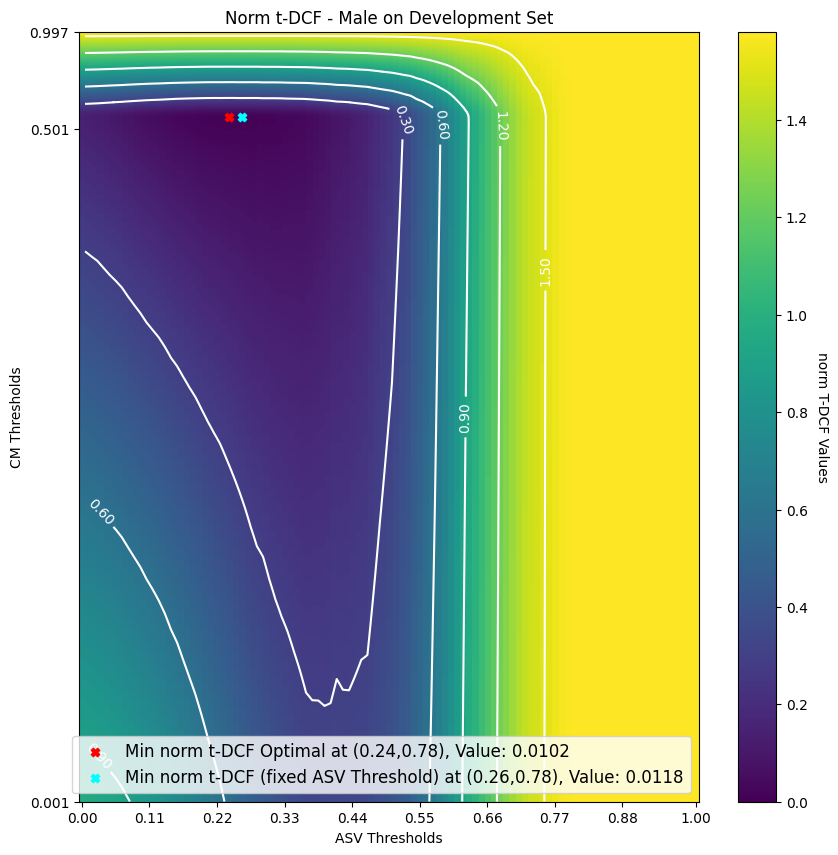

In [78]:
heatmap_norm_tdcf(list_tDCF_norm_male_dev,list_asv_score,list_CM_thresholds_male_dev, target_values = [0,0.5,1],title ="Norm t-DCF - Male on Development Set",point_x_index=min_index[0], point_y_index=min_index[1],point_x_constrained=point_x_constrained,point_y_constrained=point_y_constrained)

## Female - DEV:

### with labels of gender:

In [79]:
labels_dev_female = torch.Tensor(Dev_dataset_all.is_spoofed[(Dev_dataset_all.sex == 'female').values].values).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data[(Dev_dataset_all.sex == 'female').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    output = spoof_model_female(torch.Tensor(total_data).to(device))
    _ , score_dev_female = spoof_model_female.loss(torch.Tensor(output).to(device),None)
    score_dev_female = -1*score_dev_female
    
score_dev_female = score_dev_female.cpu().numpy().copy()

eer, thresh = my_functions.compute_eer(labels_dev_female,score_dev_female) # compute equal error rate

print(f"\tDev Female EER:({100*eer}%)")

	Dev Female EER:(0.0%)


c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:653: RuntimeWarning: divide by zero encountered in true_divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:656: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [80]:

bonafide_score_cm_female_dev = score_dev_female[labels_dev_female == 0].flatten()
bonafide_score_cm_female_dev = -1*bonafide_score_cm_female_dev

spoof_score_cm_female_dev = score_dev_female[labels_dev_female == 1].flatten()
spoof_score_cm_female_dev = -1*spoof_score_cm_female_dev
Prior_spoof = 0.05
target_scores_female_dev = results.loc[(results['asv_label'] ==  "target") & (results['its_male_ground_truth'] == 'female') ]["asv_score_female"].values
nontarget_scores_female_dev = results.loc[(results['asv_label'] == "nontarget") & (results['its_male_ground_truth'] == 'female') ]["asv_score_female"].values
spoof_scores_female_dev = results.loc[(results['asv_label'] ==  "spoof") & (results['its_male_ground_truth'] == 'female')]["asv_score_female"].values
list_asv_score = [0.397]
type = 'constrained'
list_tDCF_norm_female_dev ,list_CM_thresholds_female_dev,list_tDCF_female_dev  = compute_t_dcf(bonafide_score_cm_female_dev,spoof_score_cm_female_dev,Prior_spoof,target_scores_female_dev,nontarget_scores_female_dev,spoof_scores_female_dev,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=1680, Nspoof=14904] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  5.14878 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.397
the CM thresholds is:  [-0.81040074 -0.80940074 -0.80887175 ...  0.94128716  0.94251966
  0.9456234 ]
the CM threshold min is: 0.546097993850708
the tDCF_norm is

In [81]:
# # Sort target scores by index and extract the corresponding filenames
# sorted_target_scores_male_dev = results.loc[
#     (results['asv_label'] == "target")& (results['its_male_ground_truth'] == 'female'),
#     ["asv_score_female", "file_name","asv_label","speaker_id_female","spoof_score_female"]
# ].sort_index()



# # Sort nontarget scores by index and extract the corresponding filenames
# sorted_nontarget_scores_male_dev = results.loc[
#     (results['asv_label'] == "nontarget") & (results['its_male_ground_truth'] == 'female'),
#     ["asv_score_female", "file_name","asv_label","speaker_id_female","spoof_score_female"]
# ].sort_index()



# # Sort spoof scores by index and extract the corresponding filenames
# sorted_spoof_scores_male_dev = results.loc[
#     (results['asv_label'] == "spoof") & (results['its_male_ground_truth'] == 'female'),
#     ["asv_score_female", "file_name","asv_label","speaker_id_female","spoof_score_female"]
# ].sort_index()

# # Open a file to write the output
# with open("output_scores_female_dev_without_gender_classification.txt", "w") as file:
#     # Write for target scores
#     for index, row in sorted_target_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_female']
#         utterance_id = row['file_name']  # Assuming file_name contains the utterance_id
#         score = row['asv_score_female']
#         trial_type = row['asv_label']
#         score_spoof = row["spoof_score_female"]
#         file.write(f"{speaker_id} {utterance_id} {score_spoof:.4f} {score:.4f} {trial_type}\n")

#     # Write for nontarget scores
#     for index, row in sorted_nontarget_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_female']
#         utterance_id = row['file_name']
#         score = row['asv_score_female']
#         trial_type = row['asv_label']
#         score_spoof = row["spoof_score_female"]
#         file.write(f"{speaker_id} {utterance_id} {score_spoof:.4f} {score:.4f} {trial_type}\n")

#     # Write for spoof scores
#     for index, row in sorted_spoof_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_female']
#         utterance_id = row['file_name']
#         score = row['asv_score_female']
#         trial_type = row['asv_label']
#         score_spoof = row["spoof_score_female"]
#         file.write(f"{speaker_id} {utterance_id} {score_spoof:.4f} {score:.4f} {trial_type}\n")


### with pred of gender:

In [82]:
labels_dev_female_gender_classification = torch.Tensor(Dev_dataset_all.is_spoofed[gender_model.predict(Dev_dataset_all.data_for_gender_classification) == 0].values).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data[gender_model.predict(Dev_dataset_all.data_for_gender_classification) == 0]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    output = spoof_model_female(torch.Tensor(total_data).to(device))
    _ , score_dev_female_gender_classification = spoof_model_female.loss(torch.Tensor(output).to(device),None)
    score_dev_female_gender_classification = -1*score_dev_female_gender_classification
    
score_dev_female_gender_classification = score_dev_female_gender_classification.cpu().numpy().copy()

eer, thresh = my_functions.compute_eer(labels_dev_female_gender_classification,score_dev_female_gender_classification) # compute equal error rate

print(f"\tDev Female EER:({100*eer}%)")

	Dev Female EER:(0.0%)


c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:653: RuntimeWarning: divide by zero encountered in true_divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\interpolate\_interpolate.py:656: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [83]:
bonafide_score_cm_female_dev = score_dev_female[labels_dev_female_gender_classification == 0].flatten()
bonafide_score_cm_female_dev = -1*bonafide_score_cm_female_dev

spoof_score_cm_female_dev = score_dev_female[labels_dev_female_gender_classification == 1].flatten()
spoof_score_cm_female_dev = -1*spoof_score_cm_female_dev
Prior_spoof = 0.05
target_scores_female_dev = results.loc[(results['asv_label'] ==  "target") & (results['its_male'] == False) ]["asv_score_female"].values
nontarget_scores_female_dev = results.loc[(results['asv_label'] == "nontarget") & (results['its_male'] == False) ]["asv_score_female"].values
spoof_scores_female_dev = results.loc[(results['asv_label'] ==  "spoof") & (results['its_male'] == False)]["asv_score_female"].values
list_asv_score = [0.397]
type = 'constrained'
list_tDCF_norm_female_dev ,list_CM_thresholds_female_dev,list_tDCF_female_dev = compute_t_dcf(bonafide_score_cm_female_dev,spoof_score_cm_female_dev,Prior_spoof,target_scores_female_dev,nontarget_scores_female_dev,spoof_scores_female_dev,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=1680, Nspoof=14904] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  5.14878 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.397
the CM thresholds is:  [-0.81040074 -0.80940074 -0.80887175 ...  0.94128716  0.94251966
  0.9456234 ]
the CM threshold min is: 0.546097993850708
the tDCF_norm is

In [84]:
# # Sort target scores by index and extract the corresponding filenames
# sorted_target_scores_male_dev = results.loc[
#     (results['asv_label'] == "target")& (results['its_male'] == False),
#     ["asv_score_female", "file_name","asv_label","speaker_id_female","spoof_score_female"]
# ].sort_index()



# # Sort nontarget scores by index and extract the corresponding filenames
# sorted_nontarget_scores_male_dev = results.loc[
#     (results['asv_label'] == "nontarget") & (results['its_male'] == False),
#     ["asv_score_female", "file_name","asv_label","speaker_id_female","spoof_score_female"]
# ].sort_index()



# # Sort spoof scores by index and extract the corresponding filenames
# sorted_spoof_scores_male_dev = results.loc[
#     (results['asv_label'] == "spoof") & (results['its_male'] == False),
#     ["asv_score_female", "file_name","asv_label","speaker_id_female","spoof_score_female"]
# ].sort_index()

# # Open a file to write the output
# with open("output_scores_female_dev_with_gender_classification.txt", "w") as file:
#     # Write for target scores
#     for index, row in sorted_target_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_female']
#         utterance_id = row['file_name']  # Assuming file_name contains the utterance_id
#         score = row['asv_score_female']
#         trial_type = row['asv_label']
#         score_spoof = row["spoof_score_female"]
#         file.write(f"{speaker_id} {utterance_id} {score_spoof:.4f} {score:.4f} {trial_type}\n")

#     # Write for nontarget scores
#     for index, row in sorted_nontarget_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_female']
#         utterance_id = row['file_name']
#         score = row['asv_score_female']
#         trial_type = row['asv_label']
#         score_spoof = row["spoof_score_female"]
#         file.write(f"{speaker_id} {utterance_id} {score_spoof:.4f} {score:.4f} {trial_type}\n")

#     # Write for spoof scores
#     for index, row in sorted_spoof_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_female']
#         utterance_id = row['file_name']
#         score = row['asv_score_female']
#         trial_type = row['asv_label']
#         score_spoof = row["spoof_score_female"]
#         file.write(f"{speaker_id} {utterance_id} {score_spoof:.4f} {score:.4f} {trial_type}\n")


In [85]:
bonafide_score_cm_female_dev = score_dev_female[labels_dev_female_gender_classification == 0].flatten()
bonafide_score_cm_female_dev = -1*bonafide_score_cm_female_dev

spoof_score_cm_female_dev = score_dev_female[labels_dev_female_gender_classification == 1].flatten()
spoof_score_cm_female_dev = -1*spoof_score_cm_female_dev
Prior_spoof = 0.05
target_scores_female_dev = results.loc[(results['asv_label'] ==  "target") & (results['its_male'] == False) ]["asv_score_female"].values
nontarget_scores_female_dev = results.loc[(results['asv_label'] == "nontarget") & (results['its_male'] == False) ]["asv_score_female"].values
spoof_scores_female_dev = results.loc[(results['asv_label'] ==  "spoof") & (results['its_male'] == False)]["asv_score_female"].values
list_asv_score = [0.397]
type = 'constrained_ver2'
list_tDCF_norm_female_dev ,list_CM_thresholds_female_dev,list_tDCF_female_dev = compute_t_dcf(bonafide_score_cm_female_dev,spoof_score_cm_female_dev,Prior_spoof,target_scores_female_dev,nontarget_scores_female_dev,spoof_scores_female_dev,list_asv_score,type)

The t-DCF evaluation type is: constrained_ver2
t-DCF evaluation from [Nbona=1680, Nspoof=14904] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa          = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss        =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_spoof    = 10.00000 (Cost of CM falsely passing a spoof to ASV system)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
the asv threshold is from eer on asv development set  0.397
the CM thresholds is:  [-0.81040074 -0.80940074 -0.80887175 ...  0.94128716  0.94251966
  0.9456234 ]
the CM threshold min is: 0.546097993850708
the tDCF_norm is: [1.         0.99993683 0.99987365 ... 4.90050443 4.90339004 4.90627565]
the min tDCF_norm is: 0.058451745651964655
the tDCF is: [0.19169327 0.191

### Grid Search:

In [86]:
bonafide_score_cm_female_dev = score_dev_female[labels_dev_female_gender_classification == 0].flatten()
bonafide_score_cm_female_dev = -1*bonafide_score_cm_female_dev

spoof_score_cm_female_dev = score_dev_female[labels_dev_female_gender_classification == 1].flatten()
spoof_score_cm_female_dev = -1*spoof_score_cm_female_dev
Prior_spoof = 0.05
target_scores_female_dev = results.loc[(results['asv_label'] ==  "target") & (results['its_male'] == False) ]["asv_score_female"].values
nontarget_scores_female_dev = results.loc[(results['asv_label'] == "nontarget") & (results['its_male'] == False) ]["asv_score_female"].values
spoof_scores_female_dev = results.loc[(results['asv_label'] ==  "spoof") & (results['its_male'] == False)]["asv_score_female"].values
list_asv_score = np.arange(0.00, 1.01, 0.01)
type = 'unconstrained'


point_y_constrained = np.argmin(list_tDCF_norm_female_dev)
point_x_constrained = (np.abs(np.array(list_asv_score)-[0.397])).argmin()

list_tDCF_norm_female_dev ,list_CM_thresholds_female_dev,list_tDCF_female_dev  = compute_t_dcf(bonafide_score_cm_female_dev,spoof_score_cm_female_dev,Prior_spoof,target_scores_female_dev,nontarget_scores_female_dev,spoof_scores_female_dev,list_asv_score,type)

tDCF_norm_female_dev = np.array(list_tDCF_norm_female_dev)

CM_thresholds_female_dev = np.array(list_CM_thresholds_female_dev)

min_index = np.unravel_index(np.nanargmin(tDCF_norm_female_dev), tDCF_norm_female_dev.shape)

# Print the results
print("tDCF - Minimum value:", tDCF_norm_female_dev[min_index])
print("Index of minimum value:", min_index)
print("The min asv score:", list_asv_score[min_index[0]])
print("The min CM thersholds:",CM_thresholds_female_dev[min_index])

The t-DCF evaluation type is: unconstrained
t-DCF evaluation from [Nbona=1680, Nspoof=14904] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa          = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss        =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_spoof    = 10.00000 (Cost of CM falsely passing a spoof to ASV system)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
the asv threshold is from eer on asv development set  0.0
the CM thresholds is:  [-0.81040074 -0.80940074 -0.80887175 ...  0.94128716  0.94251966
  0.9456234 ]
the CM threshold min is: 0.546097993850708
the tDCF_norm is: [0.99155806 0.99150174 0.99144543 ... 1.57897175 1.57982201 1.58067227]
the min tDCF_norm is: 0.1522368206541876
the tDCF is: [0.58997704 0.58994354 0

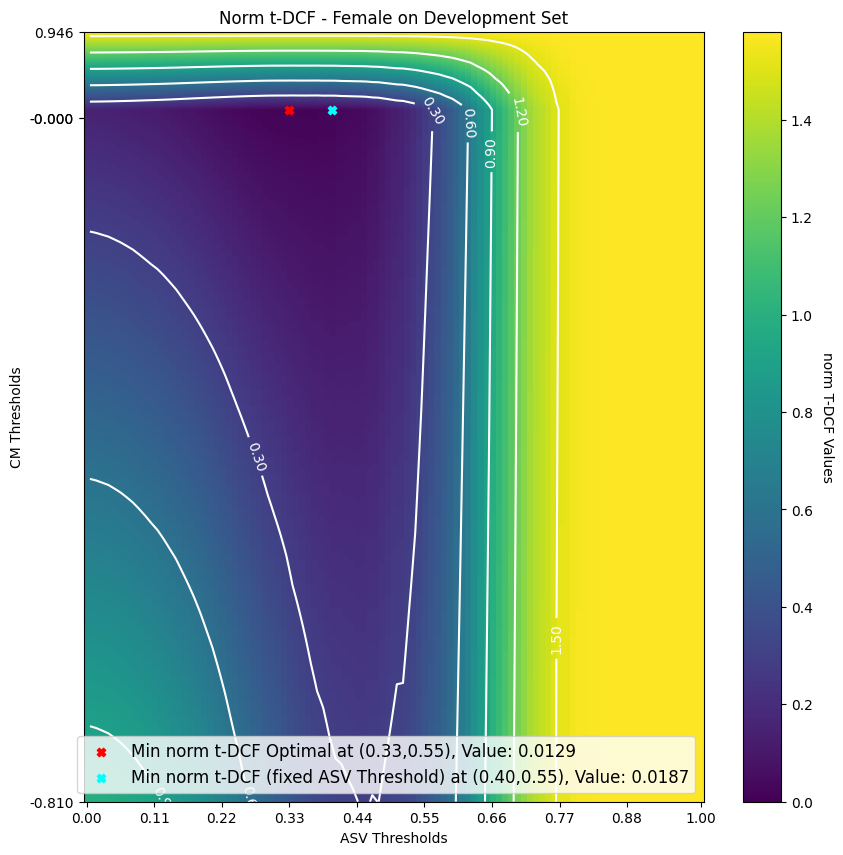

In [87]:
heatmap_norm_tdcf(list_tDCF_norm_female_dev,list_asv_score,list_CM_thresholds_female_dev, target_values = [-1,0,0,1],title ="Norm t-DCF - Female on Development Set",point_x_index = min_index[0] ,point_y_index  = min_index[1],point_x_constrained = point_x_constrained, point_y_constrained = point_y_constrained)

## Eval:

In [88]:
from sklearn.metrics.pairwise import cosine_similarity
import torchaudio
import tqdm
from ASV_utils.config_thr import pmf_both_thr_gender_val ,pmf_both_thr_spoof_test_male,pmf_both_thr_spoof_test_female

txt_file_path = "output.txt"
csv_file_path = "output.csv"
enrollment_male = enrollment_eval_male
enrollment_female = enrollment_eval_female
list_files = file_name_according_speaker_id_eval
data_set = Eval_dataset_all
asv_model = classifier
spoof_labels = spoof_label_eval
list_speaker_id = speaker_id_list_eval
list_asv_label = asv_label_eval

#results_eval = inference_system_cm_asv_avg_score(spoof_labels,list_speaker_id,list_asv_label,txt_file_path,csv_file_path,pmf_both_thr_gender_val,pmf_both_thr_spoof_test_male,pmf_both_thr_spoof_test_female,enrollment_male, enrollment_female, list_files, data_set, gender_model, spoof_model_male, spoof_model_female, asv_model, device, verbose = False, verbose_txt = False,verbose_csv = False)

In [89]:

import pickle
#with open('objects_asv_and_cm_time_embeddings_eval_avg_score_both_asv_protocol.pkl', 'wb') as f:
#    pickle.dump(results_eval,f)


In [90]:
from ASV_utils.tdcf_functions import compute_t_dcf


import pickle
with open('./dcf_and_tdcf\dcf_avg_score/pmf_both_tdcf/asv_protocol/objects_asv_and_cm_time_embeddings_eval_avg_score_both_asv_protocol.pkl', 'rb') as f:
    results_eval = pickle.load(f)


## Male - Eval:

### with labels of gender:

In [91]:
labels_eval_male = torch.Tensor(Eval_dataset_all.is_spoofed[(Eval_dataset_all.sex == 'male').values].values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data[(Eval_dataset_all.sex == 'male').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    score_eval_male = torch.sigmoid(spoof_model_male(torch.Tensor(total_data).to(device)))
    
score_eval_male = score_eval_male.cpu().numpy().copy()

eer_eval_male, _ = my_functions.compute_eer(labels_eval_male,score_eval_male) # compute equal error rate

print(f"\t Eval Male EER: ({100*eer_eval_male}%)")

	 Eval Male EER: (8.672798948696906%)


In [92]:

bonafide_score_cm_male_eval = 1-score_eval_male[labels_eval_male == 0].flatten()
spoof_score_cm_male_eval = 1-score_eval_male[labels_eval_male == 1].flatten()
Prior_spoof = 0.05
target_scores_male_eval = results_eval.loc[(results_eval['asv_label'] ==  "target") & (results_eval['its_male_ground_truth'] == 'male') ]["asv_score_male"].values
nontarget_scores_male_eval = results_eval.loc[(results_eval['asv_label'] == "nontarget") & (results_eval['its_male_ground_truth'] == 'male') ]["asv_score_male"].values
spoof_scores_male_eval = results_eval.loc[(results_eval['asv_label'] ==  "spoof") & (results_eval['its_male_ground_truth'] == 'male')]["asv_score_male"].values
list_asv_score = [0.261,0.352]
type = 'constrained'
list_tDCF_norm_male_eval ,list_CM_thresholds_male_eval,list_tDCF_male_eval  = compute_t_dcf(bonafide_score_cm_male_eval,spoof_score_cm_male_eval,Prior_spoof,target_scores_male_eval,nontarget_scores_male_eval,spoof_scores_male_eval,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=2283, Nspoof=19656] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.46362 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.261
the CM thresholds is:  [4.97268677e-04 1.49726868e-03 1.50895119e-03 ... 9.96871948e-01
 9.96981561e-01 9.97154653e-01]
the CM threshold min is: 0.90961152315139

In [93]:
# # Sort target scores by index and extract the corresponding filenames
# results = results_eval
# sorted_target_scores_male_dev = results.loc[
#     (results['asv_label'] == "target")& (results['its_male_ground_truth'] == 'male'),
#     ["asv_score_male", "file_name","asv_label","speaker_id_male"]
# ].sort_index()



# # Sort nontarget scores by index and extract the corresponding filenames
# sorted_nontarget_scores_male_dev = results.loc[
#     (results['asv_label'] == "nontarget") & (results['its_male_ground_truth'] == 'male'),
#     ["asv_score_male", "file_name","asv_label","speaker_id_male"]
# ].sort_index()



# # Sort spoof scores by index and extract the corresponding filenames
# sorted_spoof_scores_male_dev = results.loc[
#     (results['asv_label'] == "spoof") & (results['its_male_ground_truth'] == 'male'),
#     ["asv_score_male", "file_name","asv_label","speaker_id_male"]
# ].sort_index()

# # Open a file to write the output
# with open("output_scores_male_eval_without_gender_classification.txt", "w") as file:
#     # Write for target scores
#     for index, row in sorted_target_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_male']
#         utterance_id = row['file_name']  # Assuming file_name contains the utterance_id
#         score = row['asv_score_male']
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")

#     # Write for nontarget scores
#     for index, row in sorted_nontarget_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_male']
#         utterance_id = row['file_name']
#         score = row['asv_score_male']
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")

#     # Write for spoof scores
#     for index, row in sorted_spoof_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_male']
#         utterance_id = row['file_name']
#         score = row['asv_score_male']
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")


### with pred of gender:

In [94]:
labels_eval_male_gender_classification = torch.Tensor(Eval_dataset_all.is_spoofed[gender_model.predict(Eval_dataset_all.data_for_gender_classification) == 1]).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data[gender_model.predict(Eval_dataset_all.data_for_gender_classification) == 1]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    score_eval_male_gender_classification = torch.sigmoid(spoof_model_male(torch.Tensor(total_data).to(device)))
    
score_eval_male_gender_classification = score_eval_male_gender_classification.cpu().numpy().copy()

eval_male_eer, _ = my_functions.compute_eer(labels_eval_male_gender_classification,score_eval_male_gender_classification) # compute equal error rate

print(f"\tEval male with gender classification EER: ({100*eval_male_eer}%) ")

	Eval male with gender classification EER: (8.522727272757948%) 


In [95]:

bonafide_score_cm_male_eval = 1-score_eval_male_gender_classification[labels_eval_male_gender_classification == 0].flatten()
spoof_score_cm_male_eval = 1-score_eval_male_gender_classification[labels_eval_male_gender_classification == 1].flatten()

Prior_spoof = 0.05
target_scores_male_eval = results_eval.loc[(results_eval['asv_label'] ==  "target") & (results_eval['its_male'] == True) ]["asv_score_male"].values
nontarget_scores_male_eval = results_eval.loc[(results_eval['asv_label'] == "nontarget") & (results_eval['its_male'] == True) ]["asv_score_male"].values
spoof_scores_male_eval = results_eval.loc[(results_eval['asv_label'] ==  "spoof") & (results_eval['its_male'] == True)]["asv_score_male"].values
list_asv_score = [0.261,0.352]
type = 'constrained'
list_tDCF_norm_male_eval ,list_CM_thresholds_male_eval,list_tDCF_male_eval  = compute_t_dcf(bonafide_score_cm_male_eval,spoof_score_cm_male_eval,Prior_spoof,target_scores_male_eval,nontarget_scores_male_eval,spoof_scores_male_eval,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=2288, Nspoof=20331] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.55266 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.261
the CM thresholds is:  [4.97268677e-04 1.49726868e-03 1.50895119e-03 ... 9.96871948e-01
 9.96981561e-01 9.97154653e-01]
the CM threshold min is: 0.90961152315139

In [96]:
# #Sort target scores by index and extract the corresponding filenames
# results = results_eval
# sorted_target_scores_male_dev = results.loc[
#     (results['asv_label'] == "target") & (results['its_male'] == True),
#     ["asv_score_male", "file_name","asv_label","speaker_id_male","speaker_id_female","asv_score_female"]
# ].sort_index()



# # Sort nontarget scores by index and extract the corresponding filenames
# sorted_nontarget_scores_male_dev = results.loc[
#     (results['asv_label'] == "nontarget") & (results['its_male'] == True),
#     ["asv_score_male", "file_name","asv_label","speaker_id_male","speaker_id_female","asv_score_female"]
# ].sort_index()



# # Sort spoof scores by index and extract the corresponding filenames
# sorted_spoof_scores_male_dev = results.loc[
#     (results['asv_label'] == "spoof") & (results['its_male'] == True),
#     ["asv_score_male", "file_name","asv_label","speaker_id_male","speaker_id_female","asv_score_female"]
# ].sort_index()

# # Open a file to write the output
# with open("output_scores_male_eval_with_gender_classification.txt", "w") as file:
#     # Write for target scores
#     for index, row in sorted_target_scores_male_dev.iterrows():
#         # Choose the appropriate speaker_id
#         speaker_id = row['speaker_id_male'] if row['speaker_id_male'] is not None else row['speaker_id_female']
        
#         # Choose the appropriate score
#         score = row['asv_score_male'] if row['asv_score_male'] != 0 else row['asv_score_female']
        
#         utterance_id = row['file_name']  # Assuming file_name contains the utterance_id
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")

#     # Write for nontarget scores
#     for index, row in sorted_nontarget_scores_male_dev.iterrows():
#         # Choose the appropriate speaker_id
#         speaker_id = row['speaker_id_male'] if row['speaker_id_male'] is not None else row['speaker_id_female']
        
#         # Choose the appropriate score
#         score = row['asv_score_male'] if row['asv_score_male'] != 0 else row['asv_score_female']
        
#         utterance_id = row['file_name']
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")

#     # Write for spoof scores
#     for index, row in sorted_spoof_scores_male_dev.iterrows():
#         # Choose the appropriate speaker_id
#         speaker_id = row['speaker_id_male'] if row['speaker_id_male'] is not None else row['speaker_id_female']
        
#         # Choose the appropriate score
#         score = row['asv_score_male'] if row['asv_score_male'] != 0 else row['asv_score_female']
        
#         utterance_id = row['file_name']
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")


In [97]:

bonafide_score_cm_male_eval = 1-score_eval_male_gender_classification[labels_eval_male_gender_classification == 0].flatten()
spoof_score_cm_male_eval = 1-score_eval_male_gender_classification[labels_eval_male_gender_classification == 1].flatten()
Prior_spoof = 0.05
target_scores_male_eval = results_eval.loc[(results_eval['asv_label'] ==  "target") & (results_eval['its_male'] == True) ]["asv_score_male"].values
nontarget_scores_male_eval = results_eval.loc[(results_eval['asv_label'] == "nontarget") & (results_eval['its_male'] == True) ]["asv_score_male"].values
spoof_scores_male_eval = results_eval.loc[(results_eval['asv_label'] ==  "spoof") & (results_eval['its_male'] == True)]["asv_score_male"].values
list_asv_score = [0.261,0.352]
type = 'constrained_ver2'
list_tDCF_norm_male_eval ,list_CM_thresholds_male_eval,list_tDCF_male_eval  = compute_t_dcf(bonafide_score_cm_male_eval,spoof_score_cm_male_eval,Prior_spoof,target_scores_male_eval,nontarget_scores_male_eval,spoof_scores_male_eval,list_asv_score,type)

The t-DCF evaluation type is: constrained_ver2
t-DCF evaluation from [Nbona=2288, Nspoof=20331] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa          = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss        =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_spoof    = 10.00000 (Cost of CM falsely passing a spoof to ASV system)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
the asv threshold is from eer on asv development set  0.261
the CM thresholds is:  [4.97268677e-04 1.49726868e-03 1.50895119e-03 ... 9.96871948e-01
 9.96981561e-01 9.97154653e-01]
the CM threshold min is: 0.9096115231513977
the tDCF_norm is: [1.         0.99995241 0.99990482 ... 2.50006582 2.50114526 2.50222469]
the min tDCF_norm is: 0.23850558205427747
the tDCF is:

In [98]:
bonafide_score_cm_male_eval = 1-score_eval_male_gender_classification[labels_eval_male_gender_classification == 0].flatten()
spoof_score_cm_male_eval = 1-score_eval_male_gender_classification[labels_eval_male_gender_classification == 1].flatten()
Prior_spoof = 0.05
target_scores_male_eval = results_eval.loc[(results_eval['asv_label'] ==  "target") & (results_eval['its_male_ground_truth'] == 'male') ]["asv_score_male"].values
nontarget_scores_male_eval = results_eval.loc[(results_eval['asv_label'] == "nontarget") & (results_eval['its_male_ground_truth'] == 'male') ]["asv_score_male"].values
spoof_scores_male_eval = results_eval.loc[(results_eval['asv_label'] ==  "spoof") & (results_eval['its_male_ground_truth'] == 'male')]["asv_score_male"].values
list_asv_score = np.arange(0, 1.01, 0.01)
type = 'unconstrained'

point_y_constrained = np.argmin(list_tDCF_norm_male_eval[1])
point_x_constrained = (np.abs(np.array(list_asv_score)-[0.352])).argmin()

list_tDCF_norm_male_eval ,list_CM_thresholds_male_eval,list_tDCF_male_eval = compute_t_dcf(bonafide_score_cm_male_eval,spoof_score_cm_male_eval,Prior_spoof,target_scores_male_eval,nontarget_scores_male_eval,spoof_scores_male_eval,list_asv_score,type)

tDCF_norm_male_eval = np.array(list_tDCF_norm_male_eval)

CM_thresholds_male_eval = np.array(list_CM_thresholds_male_eval)

min_index = np.unravel_index(np.nanargmin(tDCF_norm_male_eval), tDCF_norm_male_eval.shape)

# Print the results
print("tDCF - Minimum value:", tDCF_norm_male_eval[min_index])
print("Index of minimum value:", min_index)
print("The min asv score:", list_asv_score[min_index[0]])
print("The min CM thersholds:",CM_thresholds_male_eval[min_index])

The t-DCF evaluation type is: unconstrained
t-DCF evaluation from [Nbona=2288, Nspoof=20331] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa          = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss        =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_spoof    = 10.00000 (Cost of CM falsely passing a spoof to ASV system)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
the asv threshold is from eer on asv development set  0.0
the CM thresholds is:  [4.97268677e-04 1.49726868e-03 1.50895119e-03 ... 9.96871948e-01
 9.96981561e-01 9.97154653e-01]
the CM threshold min is: 0.916646420955658
the tDCF_norm is: [0.98089971 0.98085868 0.98081766 ... 1.57941889 1.58004558 1.58067227]
the min tDCF_norm is: 0.30593341539639346
the tDCF is: [0.58

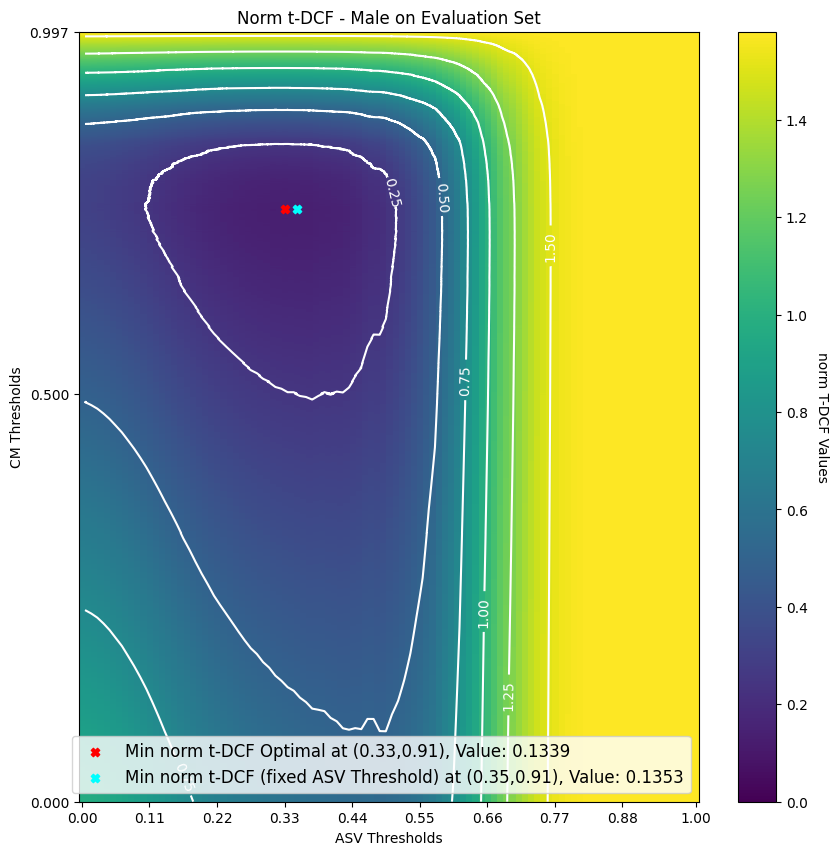

In [99]:
heatmap_norm_tdcf(list_tDCF_norm_male_eval,list_asv_score,list_CM_thresholds_male_eval, target_values = [0,0.5,1],title ="Norm t-DCF - Male on Evaluation Set",point_x_index=min_index[0], point_y_index=min_index[1],point_x_constrained=point_x_constrained,point_y_constrained=point_y_constrained)

In [100]:
# thr from validation set
list_asv_score = [0.261,0.352]
CM_thr = pmf_both_thr_spoof_test_male
ASV_thr = list_asv_score[0]
spoof_score_cm_male_eval = results_eval.loc[(results_eval['its_male'] == True)]['spoof_score_male']
think_is_geninue = spoof_score_cm_male_eval.loc[spoof_score_cm_male_eval<CM_thr] 
print(results_eval.loc[think_is_geninue.index]['asv_label'].value_counts())

to_asv = results_eval.loc[(think_is_geninue.index)]
print(to_asv.loc[to_asv['asv_score_male']>ASV_thr]['asv_label'].value_counts())
print("--------------------------------------------------")
## all the files inside the system cm -> inside -> asv
indexes = []
path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) 
for file in results_eval.loc[think_is_geninue.index]['file_name'].values:
    index = path_name.str.contains(file)
    indexes.append(index.loc[index==True].index[0])
print(Eval_dataset_all.attack_logical[indexes].value_counts())
print("--------------------------------------------------")
## all the files inside the system cm -> asv -> inside
indexes = []
path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) 
for file in to_asv.loc[to_asv['asv_score_male']>ASV_thr]['file_name'].values:
    index = path_name.str.contains(file)
    indexes.append(index.loc[index==True].index[0])
print(Eval_dataset_all.attack_logical[indexes].value_counts())
print("--------------------------------------------------")

asv_label
nontarget    10992
spoof         1836
target        1290
Name: count, dtype: int64
asv_label
target       1285
nontarget     788
spoof         454
Name: count, dtype: int64
--------------------------------------------------
[none]    12282
[A17]       889
[A18]       694
[A15]       163
[A10]        32
[A11]        29
[A14]        22
[A09]         7
Name: count, dtype: int64
--------------------------------------------------
[none]    2073
[A18]      167
[A15]      163
[A17]       41
[A10]       31
[A11]       29
[A14]       22
[A09]        1
Name: count, dtype: int64
--------------------------------------------------


In [101]:
# thr from test set
CM_thr = pmf_both_thr_spoof_test_male
ASV_thr = list_asv_score[1]
spoof_score_cm_male_eval = results_eval.loc[(results_eval['its_male'] == True)]['spoof_score_male']
think_is_geninue = spoof_score_cm_male_eval.loc[spoof_score_cm_male_eval<CM_thr] 
print(results_eval.loc[think_is_geninue.index]['asv_label'].value_counts())

to_asv = results_eval.loc[(think_is_geninue.index)]
print(to_asv.loc[to_asv['asv_score_male']>ASV_thr]['asv_label'].value_counts())
print("--------------------------------------------------")
## all the files inside the system cm -> inside -> asv
indexes = []
path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) 
for file in results_eval.loc[think_is_geninue.index]['file_name'].values:
    index = path_name.str.contains(file)
    indexes.append(index.loc[index==True].index[0])
print(Eval_dataset_all.attack_logical[indexes].value_counts())
print("--------------------------------------------------")
## all the files inside the system cm -> asv -> inside
indexes = []
path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) 
for file in to_asv.loc[to_asv['asv_score_male']>ASV_thr]['file_name'].values:
    index = path_name.str.contains(file)
    indexes.append(index.loc[index==True].index[0])
print(Eval_dataset_all.attack_logical[indexes].value_counts())
print("--------------------------------------------------")

asv_label
nontarget    10992
spoof         1836
target        1290
Name: count, dtype: int64
asv_label
target       1278
spoof         279
nontarget      75
Name: count, dtype: int64
--------------------------------------------------
[none]    12282
[A17]       889
[A18]       694
[A15]       163
[A10]        32
[A11]        29
[A14]        22
[A09]         7
Name: count, dtype: int64
--------------------------------------------------
[none]    1353
[A15]      157
[A18]       40
[A10]       30
[A11]       28
[A14]       21
[A17]        3
Name: count, dtype: int64
--------------------------------------------------


In [102]:
list_asv_score = np.arange(0, 1.01, 0.01)
CM_thr = 1-CM_thresholds_male_eval[min_index]
ASV_thr = list_asv_score[min_index[0]]
spoof_score_cm_male_eval = results_eval.loc[(results_eval['its_male'] == True)]['spoof_score_male']
think_is_geninue = spoof_score_cm_male_eval.loc[spoof_score_cm_male_eval<CM_thr] 
print(results_eval.loc[think_is_geninue.index]['asv_label'].value_counts())

to_asv = results_eval.loc[(think_is_geninue.index)]
print(to_asv.loc[to_asv['asv_score_male']>ASV_thr]['asv_label'].value_counts())
print("--------------------------------------------------")
## all the files inside the system cm -> inside -> asv
indexes = []
path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) 
for file in results_eval.loc[think_is_geninue.index]['file_name'].values:
    index = path_name.str.contains(file)
    indexes.append(index.loc[index==True].index[0])
print(Eval_dataset_all.attack_logical[indexes].value_counts())
print("--------------------------------------------------")
## all the files inside the system cm -> asv -> inside
indexes = []
path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) 
for file in to_asv.loc[to_asv['asv_score_male']>ASV_thr]['file_name'].values:
    index = path_name.str.contains(file)
    indexes.append(index.loc[index==True].index[0])
print(Eval_dataset_all.attack_logical[indexes].value_counts())
print("--------------------------------------------------")

asv_label
nontarget    11674
spoof         2792
target        1373
Name: count, dtype: int64
asv_label
target       1365
spoof         726
nontarget     140
Name: count, dtype: int64
--------------------------------------------------
[none]    13047
[A17]      1064
[A18]      1064
[A15]       351
[A10]       114
[A11]        85
[A14]        76
[A09]        26
[A12]        10
[A13]         1
[A19]         1
Name: count, dtype: int64
--------------------------------------------------
[none]    1505
[A15]      344
[A10]      111
[A18]       98
[A11]       84
[A14]       75
[A12]        8
[A17]        5
[A13]        1
Name: count, dtype: int64
--------------------------------------------------


## Female - Eval:

### with labels of gender:

In [103]:
labels_eval_female = torch.Tensor(Eval_dataset_all.is_spoofed[(Eval_dataset_all.sex == 'female').values].values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data[(Eval_dataset_all.sex == 'female').values]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    output = spoof_model_female(torch.Tensor(total_data).to(device))
    _ , score_eval_female = spoof_model_female.loss(torch.Tensor(output).to(device),None)
    score_eval_female = -1*score_eval_female
    
score_eval_female = score_eval_female.cpu().numpy().copy()

eer_eval_female, _ = my_functions.compute_eer(labels_eval_female,score_eval_female) # compute equal error rate

print(f"\tEval Female labels gender EER: ({eer_eval_female}%)")

	Eval Female labels gender EER: (0.10129787907565715%)


In [104]:
bonafide_score_cm_female_eval = score_eval_female[labels_eval_female == 0]
bonafide_score_cm_female_eval = -1*bonafide_score_cm_female_eval

spoof_score_cm_female_eval = score_eval_female[labels_eval_female == 1]
spoof_score_cm_female_eval  = -1*spoof_score_cm_female_eval

Prior_spoof = 0.05

target_scores_female_eval = results_eval.loc[(results_eval['asv_label'] ==  "target") & (results_eval['its_male_ground_truth'] == 'female') ]["asv_score_female"].values
nontarget_scores_female_eval = results_eval.loc[(results_eval['asv_label'] == "nontarget") & (results_eval['its_male_ground_truth'] == 'female') ]["asv_score_female"].values
spoof_scores_female_eval = results_eval.loc[(results_eval['asv_label'] ==  "spoof") & (results_eval['its_male_ground_truth'] == 'female')]["asv_score_female"].values

list_asv_score = [0.397,0.401]
type = 'constrained'
list_tDCF_norm_female_eval ,list_CM_thresholds_female_eval,list_tDCF_female_eval  = compute_t_dcf(bonafide_score_cm_female_eval,spoof_score_cm_female_eval,Prior_spoof,target_scores_female_eval,nontarget_scores_female_eval,spoof_scores_female_eval,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=5072, Nspoof=44226] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.97596 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.397
the CM thresholds is:  [-0.82588501 -0.82488501 -0.82439852 ...  0.94250655  0.94292605
  0.95455754]
the CM threshold min is: 0.7508225440979004
the tDCF_norm i

In [105]:
# # Sort target scores by index and extract the corresponding filenames
# results = results_eval
# sorted_target_scores_male_dev = results.loc[
#     (results['asv_label'] == "target")& (results['its_male_ground_truth'] == 'female'),
#     ["asv_score_female", "file_name","asv_label","speaker_id_female"]
# ].sort_index()



# # Sort nontarget scores by index and extract the corresponding filenames
# sorted_nontarget_scores_male_dev = results.loc[
#     (results['asv_label'] == "nontarget") & (results['its_male_ground_truth'] == 'female'),
#     ["asv_score_female", "file_name","asv_label","speaker_id_female"]
# ].sort_index()



# # Sort spoof scores by index and extract the corresponding filenames
# sorted_spoof_scores_male_dev = results.loc[
#     (results['asv_label'] == "spoof") & (results['its_male_ground_truth'] == 'female'),
#     ["asv_score_female", "file_name","asv_label","speaker_id_female"]
# ].sort_index()

# # Open a file to write the output
# with open("output_scores_female_eval_without_gender_classification.txt", "w") as file:
#     # Write for target scores
#     for index, row in sorted_target_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_female']
#         utterance_id = row['file_name']  # Assuming file_name contains the utterance_id
#         score = row['asv_score_female']
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")

#     # Write for nontarget scores
#     for index, row in sorted_nontarget_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_female']
#         utterance_id = row['file_name']
#         score = row['asv_score_female']
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")

#     # Write for spoof scores
#     for index, row in sorted_spoof_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id_female']
#         utterance_id = row['file_name']
#         score = row['asv_score_female']
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")


### with pred of gender:

In [106]:
labels_eval_female_gender_classification = torch.Tensor(Eval_dataset_all.is_spoofed[gender_model.predict(Eval_dataset_all.data_for_gender_classification) == 0].values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data[gender_model.predict(Eval_dataset_all.data_for_gender_classification) == 0]).cpu().numpy().copy()
with torch.no_grad():
    model = model.to(device)
    output = spoof_model_female(torch.Tensor(total_data).to(device))
    _ , score_eval_female_gender_classification = spoof_model_female.loss(torch.Tensor(output).to(device),None)
    score_eval_female_gender_classification = -1*score_eval_female_gender_classification
    
score_eval_female_gender_classification = score_eval_female_gender_classification.cpu().numpy().copy()

eer, _ = my_functions.compute_eer(labels_eval_female_gender_classification,score_eval_female_gender_classification) # compute equal error rate

print(f"\tDev Female EER:({100*eer}%)")

	Dev Female EER:(10.227090078299229%)


In [107]:
bonafide_score_cm_female_eval = score_eval_female_gender_classification[labels_eval_female_gender_classification == 0]
bonafide_score_cm_female_eval = -1*bonafide_score_cm_female_eval

spoof_score_cm_female_eval = score_eval_female_gender_classification[labels_eval_female_gender_classification == 1]
spoof_score_cm_female_eval  = -1*spoof_score_cm_female_eval

Prior_spoof = 0.05

target_scores_female_eval = results_eval.loc[(results_eval['asv_label'] ==  "target") & (results_eval['its_male'] == False) ]["asv_score_female"].values
nontarget_scores_female_eval = results_eval.loc[(results_eval['asv_label'] == "nontarget") & (results_eval['its_male'] == False) ]["asv_score_female"].values
spoof_scores_female_eval = results_eval.loc[(results_eval['asv_label'] ==  "spoof") & (results_eval['its_male'] == False)]["asv_score_female"].values

list_asv_score = [0.397,0.401]
type = 'constrained'
list_tDCF_norm_female_eval ,list_CM_thresholds_female_eval,list_tDCF_female_eval  = compute_t_dcf(bonafide_score_cm_female_eval,spoof_score_cm_female_eval,Prior_spoof,target_scores_female_eval,nontarget_scores_female_eval,spoof_scores_female_eval,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=5067, Nspoof=43551] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.95911 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.397
the CM thresholds is:  [-0.82588501 -0.82488501 -0.82439852 ...  0.94250655  0.94292593
  0.95455754]
the CM threshold min is: 0.7508225440979004
the tDCF_norm i

In [108]:
# #Sort target scores by index and extract the corresponding filenames
# results = results_eval
# sorted_target_scores_male_dev = results.loc[
#     (results['asv_label'] == "target") & (results['its_male'] == False),
#     ["asv_score_male", "file_name","asv_label","speaker_id_male","speaker_id_female","asv_score_female"]
# ].sort_index()



# # Sort nontarget scores by index and extract the corresponding filenames
# sorted_nontarget_scores_male_dev = results.loc[
#     (results['asv_label'] == "nontarget") & (results['its_male'] == False),
#     ["asv_score_male", "file_name","asv_label","speaker_id_male","speaker_id_female","asv_score_female"]
# ].sort_index()



# # Sort spoof scores by index and extract the corresponding filenames
# sorted_spoof_scores_male_dev = results.loc[
#     (results['asv_label'] == "spoof") & (results['its_male'] == False),
#     ["asv_score_male", "file_name","asv_label","speaker_id_male","speaker_id_female","asv_score_female"]
# ].sort_index()

# # Open a file to write the output
# with open("output_scores_female_eval_with_gender_classification.txt", "w") as file:
#     # Write for target scores
#     for index, row in sorted_target_scores_male_dev.iterrows():
#         # Choose the appropriate speaker_id
#         speaker_id = row['speaker_id_female'] if row['speaker_id_female'] is not None else row['speaker_id_male']
        
#         # Choose the appropriate score
#         score = row['asv_score_female'] if row['asv_score_female'] != 0 else row['asv_score_male']
        
#         utterance_id = row['file_name']  # Assuming file_name contains the utterance_id
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")

#     # Write for nontarget scores
#     for index, row in sorted_nontarget_scores_male_dev.iterrows():
#         # Choose the appropriate speaker_id
#         speaker_id = row['speaker_id_female'] if row['speaker_id_female'] is not None else row['speaker_id_male']
        
#         # Choose the appropriate score
#         score = row['asv_score_female'] if row['asv_score_female'] != 0 else row['asv_score_male']
        
#         utterance_id = row['file_name']
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")

#     # Write for spoof scores
#     for index, row in sorted_spoof_scores_male_dev.iterrows():
#         # Choose the appropriate speaker_id
#         speaker_id = row['speaker_id_female'] if row['speaker_id_female'] is not None else row['speaker_id_male']
        
#         # Choose the appropriate score
#         score = row['asv_score_female'] if row['asv_score_female'] != 0 else row['asv_score_male']
        
#         utterance_id = row['file_name']
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")


In [109]:
bonafide_score_cm_female_eval = score_eval_female_gender_classification[labels_eval_female_gender_classification == 0]
bonafide_score_cm_female_eval = -1*bonafide_score_cm_female_eval

spoof_score_cm_female_eval = score_eval_female_gender_classification[labels_eval_female_gender_classification == 1]
spoof_score_cm_female_eval  = -1*spoof_score_cm_female_eval

Prior_spoof = 0.05

target_scores_female_eval = results_eval.loc[(results_eval['asv_label'] ==  "target") & (results_eval['its_male'] == False) ]["asv_score_female"].values
nontarget_scores_female_eval = results_eval.loc[(results_eval['asv_label'] == "nontarget") & (results_eval['its_male'] == False) ]["asv_score_female"].values
spoof_scores_female_eval = results_eval.loc[(results_eval['asv_label'] ==  "spoof") & (results_eval['its_male'] == False)]["asv_score_female"].values

list_asv_score = [0.397,0.401]
type = 'constrained_ver2'
list_tDCF_norm_female_eval ,list_CM_thresholds_female_eval,list_tDCF_female_eval  = compute_t_dcf(bonafide_score_cm_female_eval,spoof_score_cm_female_eval,Prior_spoof,target_scores_female_eval,nontarget_scores_female_eval,spoof_scores_female_eval,list_asv_score,type)

The t-DCF evaluation type is: constrained_ver2
t-DCF evaluation from [Nbona=5067, Nspoof=43551] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa          = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss        =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_spoof    = 10.00000 (Cost of CM falsely passing a spoof to ASV system)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
the asv threshold is from eer on asv development set  0.397
the CM thresholds is:  [-0.82588501 -0.82488501 -0.82439852 ...  0.94250655  0.94292593
  0.95455754]
the CM threshold min is: 0.7508225440979004
the tDCF_norm is: [1.         0.99997769 0.99995538 ... 2.90313065 2.90310834 2.90367581]
the min tDCF_norm is: 0.3140309099821646
the tDCF is: [0.3238998  0.3238

In [110]:
bonafide_score_cm_female_eval = score_eval_female_gender_classification[labels_eval_female_gender_classification == 0]
bonafide_score_cm_female_eval = -1*bonafide_score_cm_female_eval

spoof_score_cm_female_eval = score_eval_female_gender_classification[labels_eval_female_gender_classification == 1]
spoof_score_cm_female_eval  = -1*spoof_score_cm_female_eval

Prior_spoof = 0.05

target_scores_female_eval = results_eval.loc[(results_eval['asv_label'] ==  "target") & (results_eval['its_male'] == False) ]["asv_score_female"].values
nontarget_scores_female_eval = results_eval.loc[(results_eval['asv_label'] == "nontarget") & (results_eval['its_male'] == False) ]["asv_score_female"].values
spoof_scores_female_eval = results_eval.loc[(results_eval['asv_label'] ==  "spoof") & (results_eval['its_male'] == False)]["asv_score_female"].values

list_asv_score = np.arange(0, 1.01, 0.01)
type = 'unconstrained'

point_y_constrained = np.argmin(list_tDCF_norm_female_eval[1])
point_x_constrained = (np.abs(np.array(list_asv_score)-[0.401])).argmin()

list_tDCF_norm_female_eval ,list_CM_thresholds_female_eval,list_tDCF_female_eval  = compute_t_dcf(bonafide_score_cm_female_eval,spoof_score_cm_female_eval,Prior_spoof,target_scores_female_eval,nontarget_scores_female_eval,spoof_scores_female_eval,list_asv_score,type)


tDCF_norm_female_eval = np.array(list_tDCF_norm_female_eval)

CM_thresholds_female_eval = np.array(list_CM_thresholds_female_eval)

min_index = np.unravel_index(np.nanargmin(tDCF_norm_female_eval), tDCF_norm_female_eval.shape)

# Print the results
print("tDCF - Minimum value:", tDCF_norm_female_eval[min_index])
print("Index of minimum value:", min_index)
print("The min asv score:", list_asv_score[min_index[0]])
print("The min CM thersholds:",CM_thresholds_female_eval[min_index])


The t-DCF evaluation type is: unconstrained
t-DCF evaluation from [Nbona=5067, Nspoof=43551] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa          = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss        =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_spoof    = 10.00000 (Cost of CM falsely passing a spoof to ASV system)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
the asv threshold is from eer on asv development set  0.0
the CM thresholds is:  [-0.82588501 -0.82488501 -0.82439852 ...  0.94250655  0.94292593
  0.95455754]
the CM threshold min is: 0.7910608649253845
the tDCF_norm is: [0.98480525 0.98478613 0.984767   ... 1.58040944 1.58039032 1.58067227]
the min tDCF_norm is: 0.35656220230018104
the tDCF is: [0.58595912 0.58594774

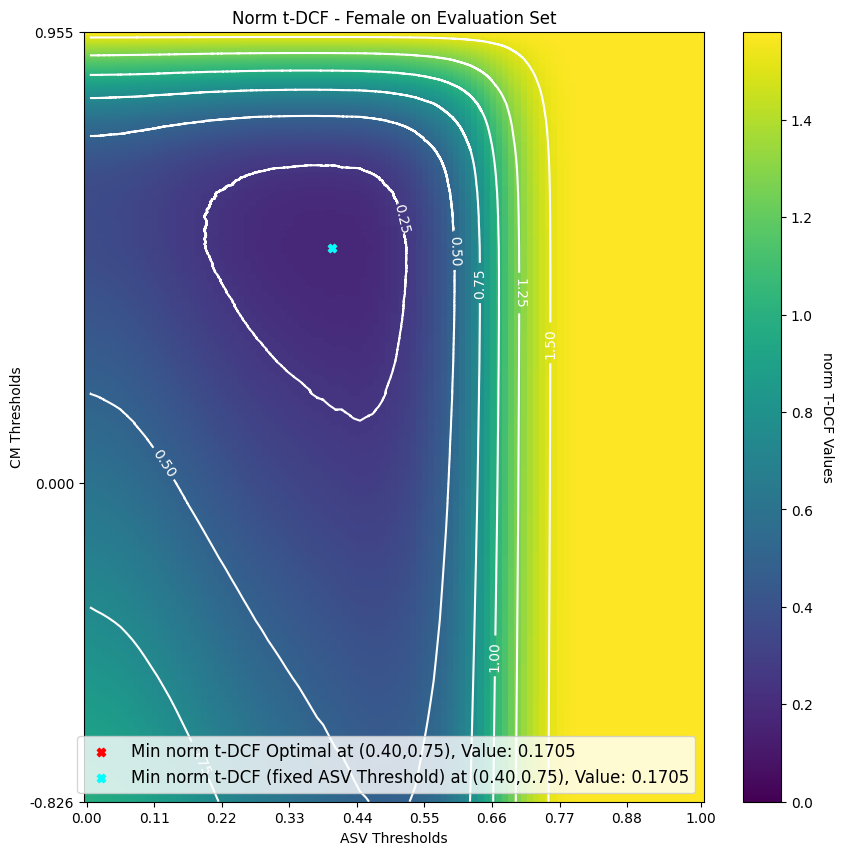

In [111]:
heatmap_norm_tdcf(list_tDCF_norm_female_eval,list_asv_score,list_CM_thresholds_female_eval, target_values = [-1,0,1],title ="Norm t-DCF - Female on Evaluation Set",point_x_index = min_index[0] ,point_y_index  = min_index[1],point_x_constrained = point_x_constrained, point_y_constrained = point_y_constrained)

In [112]:
#thr from validation set
list_asv_score = [0.397,0.401]
CM_thr = pmf_both_thr_spoof_test_female
ASV_thr = list_asv_score[0]
spoof_score_cm_female_eval = results_eval.loc[(results_eval['its_male'] == False)]['spoof_score_female']
think_is_geninue = spoof_score_cm_female_eval.loc[spoof_score_cm_female_eval<CM_thr] 
results_eval.loc[think_is_geninue.index]['asv_label'].value_counts()

print(results_eval.loc[think_is_geninue.index]['asv_label'].value_counts())

to_asv = results_eval.loc[(think_is_geninue.index)]
print(to_asv.loc[to_asv['asv_score_female']>ASV_thr]['asv_label'].value_counts())

print("--------------------------------------------------------")

## all the files inside the system cm -> inside -> asv
indexes = []
path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) 
for file in results_eval.loc[think_is_geninue.index]['file_name'].values:
    index = path_name.str.contains(file)
    indexes.append(index.loc[index==True].index[0])
print(Eval_dataset_all.attack_logical[indexes].value_counts())

print("--------------------------------------------------------")

## all the files inside the system cm -> asv -> inside
indexes = []
path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) # Get the path names of the data set
for file in to_asv.loc[to_asv['asv_score_female']>ASV_thr]['file_name'].values:
    index = path_name.str.contains(file)
    indexes.append(index.loc[index==True].index[0])
print(Eval_dataset_all.attack_logical[indexes].value_counts())

asv_label
nontarget    19183
spoof         4494
target        3523
Name: count, dtype: int64
asv_label
target       3497
spoof        1631
nontarget     153
Name: count, dtype: int64
--------------------------------------------------------
[none]    22706
[A17]      2368
[A15]      1305
[A18]       433
[A10]       260
[A14]        91
[A11]        37
Name: count, dtype: int64
--------------------------------------------------------
[none]    3650
[A15]     1270
[A10]      237
[A17]       45
[A11]       34
[A14]       33
[A18]       12
Name: count, dtype: int64


In [113]:
#thr from test set

CM_thr = pmf_both_thr_spoof_test_female
ASV_thr = list_asv_score[1]
spoof_score_cm_female_eval = results_eval.loc[(results_eval['its_male'] == False)]['spoof_score_female']
think_is_geninue = spoof_score_cm_female_eval.loc[spoof_score_cm_female_eval<CM_thr] 
results_eval.loc[think_is_geninue.index]['asv_label'].value_counts()

print(results_eval.loc[think_is_geninue.index]['asv_label'].value_counts())

to_asv = results_eval.loc[(think_is_geninue.index)]
print(to_asv.loc[to_asv['asv_score_female']>ASV_thr]['asv_label'].value_counts())

print("--------------------------------------------------------")

## all the files inside the system cm -> inside -> asv
indexes = []
path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) 
for file in results_eval.loc[think_is_geninue.index]['file_name'].values:
    index = path_name.str.contains(file)
    indexes.append(index.loc[index==True].index[0])
print(Eval_dataset_all.attack_logical[indexes].value_counts())

print("--------------------------------------------------------")

## all the files inside the system cm -> asv -> inside
indexes = []
path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) # Get the path names of the data set
for file in to_asv.loc[to_asv['asv_score_female']>ASV_thr]['file_name'].values:
    index = path_name.str.contains(file)
    indexes.append(index.loc[index==True].index[0])
print(Eval_dataset_all.attack_logical[indexes].value_counts())

asv_label
nontarget    19183
spoof         4494
target        3523
Name: count, dtype: int64
asv_label
target       3496
spoof        1618
nontarget     142
Name: count, dtype: int64
--------------------------------------------------------
[none]    22706
[A17]      2368
[A15]      1305
[A18]       433
[A10]       260
[A14]        91
[A11]        37
Name: count, dtype: int64
--------------------------------------------------------
[none]    3638
[A15]     1265
[A10]      236
[A17]       44
[A11]       34
[A14]       30
[A18]        9
Name: count, dtype: int64


In [114]:
#thr from 2 optimazation thresholds
list_asv_score = np.arange(0, 1.01, 0.01)
CM_thr = 1-CM_thresholds_female_eval[min_index]
ASV_thr = list_asv_score[min_index[0]]
spoof_score_cm_female_eval = results_eval.loc[(results_eval['its_male'] == False)]['spoof_score_female']
think_is_geninue = spoof_score_cm_female_eval.loc[spoof_score_cm_female_eval<CM_thr] 
results_eval.loc[think_is_geninue.index]['asv_label'].value_counts()

print(results_eval.loc[think_is_geninue.index]['asv_label'].value_counts())

to_asv = results_eval.loc[(think_is_geninue.index)]
print(to_asv.loc[to_asv['asv_score_female']>ASV_thr]['asv_label'].value_counts())

print("--------------------------------------------------------")

## all the files inside the system cm -> inside -> asv
indexes = []
path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) 
for file in results_eval.loc[think_is_geninue.index]['file_name'].values:
    index = path_name.str.contains(file)
    indexes.append(index.loc[index==True].index[0])
print(Eval_dataset_all.attack_logical[indexes].value_counts())

print("--------------------------------------------------------")

## all the files inside the system cm -> asv -> inside
indexes = []
path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) # Get the path names of the data set
for file in to_asv.loc[to_asv['asv_score_female']>ASV_thr]['file_name'].values:
    index = path_name.str.contains(file)
    indexes.append(index.loc[index==True].index[0])
print(Eval_dataset_all.attack_logical[indexes].value_counts())

asv_label
spoof        24781
nontarget    21267
target        3939
Name: count, dtype: int64
asv_label
spoof        15793
target        3903
nontarget      170
Name: count, dtype: int64
--------------------------------------------------------
[none]    25206
[A17]      3435
[A15]      3415
[A10]      3379
[A11]      3375
[A14]      3242
[A18]      3126
[A13]      2963
[A12]      1142
[A19]       367
[A08]       215
[A09]        90
[A16]        26
[A07]         6
Name: count, dtype: int64
--------------------------------------------------------
[none]    4073
[A15]     3361
[A10]     3181
[A11]     3158
[A14]     3042
[A13]     1698
[A12]      953
[A08]      139
[A18]      116
[A17]       63
[A19]       54
[A16]       22
[A07]        6
Name: count, dtype: int64


## without Gender speration: 

In [115]:
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss
from utils.OCSoftmaxloss import OCSoftmax
import torch.nn as nn

import torch.nn as nn
class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 
   
    def forward(self, x):
        res = x
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        x = res + x 
        return x

class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size, r_real , r_fake,alpha):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,80)
        self.BN = nn.BatchNorm1d(80)
        self.fc = nn.Linear(80, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.r_real = r_real
        self.r_fake = r_fake
        self.alpha = alpha
        self.loss = OCSoftmax(feat_dim = final_output_size, r_real = self.r_real, r_fake = self.r_fake, alpha = self.alpha)
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)


r_real = 0.9 
r_fake = 0.5
alpha = 20
input_channel_size = 10
output_channel_size = 10
num_SubChannelNetwork = 16
final_output_size = 16*2
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size,r_real = r_real , r_fake = r_fake,alpha = alpha)
model = model.to(device)


model = model.to(device) # send the model to the device


models_folder = 'Deep_Learning_Codes/best_models/fixed order/models/'
model = pickle.load(open(models_folder + "male_and_female_2_neorun_end_OCS_both.pkl", 'rb'))
model.eval()

spoof_model = copy.deepcopy(model)


In [116]:
total_labels = torch.Tensor(Dev_dataset_all.is_spoofed.values).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data_without_separation).cpu().numpy().copy()
with torch.no_grad():
    spoof_model = spoof_model.to(device)
    validation_output = spoof_model(torch.Tensor(total_data).to(device)).cpu()
    loss , validation_score = spoof_model.loss(torch.Tensor(validation_output).to(device),torch.LongTensor(total_labels).to(device))
    validation_score = -1*validation_score


test_score_total = validation_score.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels,test_score_total) # compute equal error rate
print(f"\tTest EER: ({100*eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (0.1076426264737441%) 	Test Threshold: -0.8789823616010454


In [117]:
total_labels = torch.Tensor(Eval_dataset_all.is_spoofed.values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data_without_separation).cpu().numpy().copy()
with torch.no_grad():
    spoof_model = spoof_model.to(device)
    test_output = spoof_model(torch.Tensor(total_data).to(device))
    _ , test_score = spoof_model.loss(torch.Tensor(test_output).to(device),torch.LongTensor(total_labels).to(device))
    test_score = -1*test_score
    
test_score_total = test_score.cpu().numpy().copy()

eer, test_thresh = my_functions.compute_eer(total_labels,test_score_total) # compute equal error rate


print(f"\tTest EER: ({100*eer}%) \tTest Threshold: {test_thresh}")

	Test EER: (10.210740992543693%) 	Test Threshold: -0.9951076507568362


In [118]:
def CM_inferernce_time_embeddings_without_gender(data,spoof_model,device,thr_spoof,verbose = False):
    its_spoof = None
    with torch.no_grad():
            spoof_model = spoof_model.to(device)
            test_output = spoof_model(torch.Tensor(data).unsqueeze(0).to(device))
            _ , spoof_score = spoof_model.loss(torch.Tensor(test_output).to(device),None) # fix this tomorrow!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
            spoof_score = -1*spoof_score.item()
            if verbose:
                print(f"it's male spoof with score: {spoof_score}")
            if spoof_score <= thr_spoof:
                its_spoof = False
                if verbose:
                    print("it's not spoof")
            else:
                its_spoof = True
                if verbose:
                    print("it's spoof")
            
            if its_spoof is None:
                raise Exception("its_spoof is None, need to check the inference function")
        
    return its_spoof, spoof_score

In [119]:

def inference_system_cm_asv_avg_score_without_gender(spoof_labels,list_speaker_id,list_asv_label,txt_file_path,csv_file_path,thr_spoof,enrollment, list_files, data_set, spoof_model, asv_model, device, verbose = False, verbose_txt = False,verbose_csv = False):
    '''
    This function is recognize the speaker in the data set, when the speaker don't say who he is, this task is like recognize the speaker. (Recognition task).
    '''
    
    # Initialize the dictionary with empty lists of data
    results = {  
        "file_name": [],
        "its_spoof": [],
        "spoof_score": [],
        "spoof_ground_truth": [],
        "asv_score": [],
        "speaker_id": [],
        "find_speaker_in_enroll": [],
        "asv_label": [],
        "attack_type": [],
        "in_cm_protocol": []
    }
    
    if txt_file_path is None: # If the txt file path is None, then don't write to the txt file
        verbose_txt = False
        print("The output file path is None, so the results will not be saved in txt file")
    
    if csv_file_path is None: # If the csv file path is None, then don't write to the csv file
        verbose_csv = False
        print("The output file path is None, so the results will not be saved in csv file")

    if verbose_txt: # Open the txt file      
        txt_file = open(txt_file_path, 'w')
        
    if verbose_csv: # Open the csv file
        csv_file = open(csv_file_path, 'w', newline='')
        csv_writer = csv.writer(csv_file)
        csv_writer.writerow(results.keys())
        
    path_names = pd.Series(np.concatenate(data_set.name.values)) # Get the path names of the data set

    for  speaker_id,file_name,spoof_label,asv_label in tqdm.tqdm(zip(list_speaker_id,list_files,spoof_labels,list_asv_label), total=len(list_files)): # Iterate over the list of the files
        try:
            index_time_embedding = path_names.str.contains(file_name) # Get the index of the file in the data set
            
            if index_time_embedding.size == 0 or index_time_embedding is None: # If the index is empty, then raise an error
                raise ValueError(f"File {file_name} in list files, is not present in in list paths.")

            if verbose: # Print the file name and the index
                print(f"File {file_name} in list files, is at {path_names[index_time_embedding]} in list paths.")
                
        except ValueError: # If the index is empty, then raise an error
            print(f"File {file_name} in list files, is not present in in list paths.")

        time_embedding = data_set.data_without_separation[index_time_embedding].squeeze() # Get the time embedding of the file
        attack_type = data_set.attack_logical.values[index_time_embedding][0][0]
        speaker_id_cm_protocol = data_set.speaker_id.values[index_time_embedding][0]
        
        if str(speaker_id_cm_protocol) == speaker_id[-2:]:
            results["in_cm_protocol"].append(True)
        else:
            results["in_cm_protocol"].append(False)
            
        # this function calculate the CM inference of the time embedding 
        its_spoof, spoof_score = CM_inferernce_time_embeddings_without_gender(time_embedding, spoof_model, device,thr_spoof) # this function calculate

       
        if its_spoof is None:
            raise Exception("its_spoof is None, need to check the inference function")
        
        if spoof_score is None:
            raise Exception("spoof_score is None, need to check the inference function")
        
        if spoof_label == 'bonafide':
            spoof_label = 0
        else:
            spoof_label = 1
        
        if data_set.is_spoofed.values[index_time_embedding][0] != spoof_label:
            raise Exception("The spoof label is not equal to the ground truth spoof label")
        
        
        # Append the results to the data dictionary
        results["file_name"].append(file_name)
        
        # for spoofing CM system
        results["its_spoof"].append(its_spoof)
        results["spoof_ground_truth"].append(bool(data_set.is_spoofed.values[index_time_embedding][0]))
        results["spoof_score"].append(spoof_score)
        
        # for ASV system
        results["asv_label"].append(asv_label)
        results["attack_type"].append(attack_type)
                
        signal, fs = torchaudio.load(str(path_names.values[index_time_embedding][0])) # load the signal from the path
        
        if fs != 16000: # if the sample rate is not 16000, then raise an error
            raise Exception("The sample rate is not 16000, need to check the inference function")
        
        embeddings = asv_model.encode_batch(signal)  # encode the signal
       
        embeddings = embeddings.cpu().numpy().squeeze(0) # convert the embeddings to numpy and send to cpu

        # initialize the helps variables
        find_speaker_in_enroll = False
        list_scores_speaker = []
        all_speakers_id = np.array(enrollment.get_all_speakers_id()) 

        for index_speaker,embedding_in_enroll_per_speaker in enumerate(enrollment.get_all_enrollment_embeddings()):
            embedding_in_enroll_per_speaker = np.array(embedding_in_enroll_per_speaker)
            for _,embedding_in_enroll in enumerate(embedding_in_enroll_per_speaker):
                if speaker_id == all_speakers_id[index_speaker]:
                    cos_score = cosine_similarity(embedding_in_enroll.squeeze().reshape(1, -1), embeddings.reshape(1, -1)) # calculate the cosine similarity between the embeddings
                    find_speaker_in_enroll = True
                    
                    if cos_score.shape != (1, 1): # if the cosine similarity is not scalar, then raise an error
                        raise Exception("cos_score shape is not (1,1) so is not scalar!, need to check the inference function")
                    
                    list_scores_speaker.append(cos_score.item())
                        
        asv_score = np.average(list_scores_speaker, axis = 0) # calculate the average score
        
        results["asv_score"].append(asv_score) # the score of the current embedding with the enrollment embedding
        results["speaker_id"].append(speaker_id)         
        results["find_speaker_in_enroll"].append(find_speaker_in_enroll)
            
        if verbose: # Print the results
            print(f"file_name: {results['file_name'][-1]}, its_spoof: {results['its_spoof'][-1]}, spoof_score: {results['spoof_score'][-1]}, spoof_ground_truth: {results['spoof_ground_truth'][-1]},asv_score: {results['asv_score'][-1]}, speaker_id: {results['speaker_id'][-1]} , pred_speaker_id: {results['pred_speaker_id'][-1]}, find_speaker_in_enroll: {results['find_speaker_in_enroll'][-1]} \n")
            
        if verbose_txt: # Write the results to the txt file
            txt_file.write(f"file_name: {results['file_name'][-1]}, its_spoof: {results['its_spoof'][-1]}, spoof_score: {results['spoof_score'][-1]}, spoof_ground_truth: {results['spoof_ground_truth'][-1]},asv_score: {results['asv_score'][-1]}, speaker_id: {results['speaker_id'][-1]} , pred_speaker_id: {results['pred_speaker_id'][-1]}, find_speaker_in_enroll: {results['find_speaker_in_enroll'][-1]} \n")

        if verbose_csv: # Write the results to the csv file
            last_item = {key: list(values)[-1] for key, values in results.items()} # Get the last item of each list in the dictionary
            csv_writer.writerow(last_item.values()) # Write the last item to the csv file
        
    if verbose_txt: # Close the txt file
        txt_file.close()
        
    if verbose_csv:# Close the csv file
        csv_file.close() 
           
    results_df = pd.DataFrame(results)  # Return the DataFrame
    
    return results_df

## Dev:

In [120]:
from sklearn.metrics.pairwise import cosine_similarity
import torchaudio
import tqdm
from ASV_utils.config_thr import pmf_both_thr_spoof_val_all

txt_file_path = "output.txt"
csv_file_path = "output.csv"
enrollment_all  = enrollment_dev_male + enrollment_dev_female
list_files = file_name_according_speaker_id_dev
data_set = Dev_dataset_all
asv_model = classifier
spoof_labels = spoof_label_dev
list_speaker_id = speaker_id_list_dev
list_asv_label = asv_label_dev

#results_dev_without_gender = inference_system_cm_asv_avg_score_without_gender(spoof_labels,list_speaker_id,list_asv_label,txt_file_path,csv_file_path,pmf_both_thr_spoof_val_all,enrollment_all, list_files, data_set, spoof_model, asv_model, device, verbose = False, verbose_txt = False,verbose_csv = False)

In [121]:

import pickle
#with open('results_dev_without_gender_avg_score_both_asv_protocol.pkl', 'wb') as f:
#    pickle.dump(results_dev_without_gender,f)
    

import pickle
file_path = "./dcf_and_tdcf\dcf_avg_score/pmf_both_tdcf/asv_protocol/results_dev_without_gender_avg_score_both_asv_protocol.pkl"
with open(file_path, 'rb') as file:
    results_dev_without_gender = pickle.load(file)


In [122]:
labels_dev_without_gender = torch.Tensor(Dev_dataset_all.is_spoofed.values).cpu().numpy().copy()
total_data = torch.Tensor(Dev_dataset_all.data_without_separation).cpu().numpy().copy()
with torch.no_grad():
    spoof_model = spoof_model.to(device)
    output = spoof_model(torch.Tensor(total_data).to(device)).cpu()
    _ , score_dev_without_gender  = spoof_model.loss(torch.Tensor(output).to(device),None)
    score_dev_without_gender = -1*score_dev_without_gender


score_dev_without_gender = score_dev_without_gender.cpu().numpy().copy()

eer_dev_without_gender, _ = my_functions.compute_eer(labels_dev_without_gender,score_dev_without_gender) # compute equal error rate
print(f"\tTest EER: ({100*eer_dev_without_gender}%)")

	Test EER: (0.1076426264737441%)


In [123]:
from ASV_utils.tdcf_functions import compute_t_dcf
gender = 'male'

check_male =(results_dev_without_gender['speaker_id'].isin(['LA_0073', 'LA_0071', 'LA_0070', 'LA_0076']))


bonafide_score_cm = score_dev_without_gender[(labels_dev_without_gender == 0) & (Dev_dataset_all.sex == gender)]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_dev_without_gender[(labels_dev_without_gender == 1) & (Dev_dataset_all.sex == gender)]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_dev_without_gender.loc[(results_dev_without_gender['asv_label'] == "target") & check_male]["asv_score"].values
nontarget_scores = results_dev_without_gender.loc[(results_dev_without_gender['asv_label'] == "nontarget")  & check_male]["asv_score"].values
spoof_scores = results_dev_without_gender.loc[(results_dev_without_gender['asv_label'] ==  "spoof")  & check_male]["asv_score"].values

list_asv_score = [0.375]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=868, Nspoof=7392] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  5.11547 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.375
the CM thresholds is:  [-0.99752004 -0.99652004 -0.99635762 ...  0.99956161  0.99958646
  0.9996103 ]
the CM threshold min is: 0.7412421703338623
the tDCF_norm is:

In [124]:
gender = 'female'
check_female =(results_dev_without_gender['speaker_id'].isin(['LA_0078','LA_0075','LA_0074','LA_0072','LA_0077','LA_0069']))



bonafide_score_cm = score_dev_without_gender[(labels_dev_without_gender == 0) & (Dev_dataset_all.sex == gender)]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_dev_without_gender[(labels_dev_without_gender == 1) & (Dev_dataset_all.sex == gender)]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_dev_without_gender.loc[(results_dev_without_gender['asv_label'] == "target") & check_female]["asv_score"].values
nontarget_scores = results_dev_without_gender.loc[(results_dev_without_gender['asv_label'] == "nontarget")  & check_female]["asv_score"].values
spoof_scores = results_dev_without_gender.loc[(results_dev_without_gender['asv_label'] ==  "spoof")  & check_female]["asv_score"].values

list_asv_score = [0.375]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=1680, Nspoof=14904] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  4.69769 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.375
the CM thresholds is:  [-0.99801869 -0.99701869 -0.99699306 ...  0.99943107  0.99950331
  0.99964386]
the CM threshold min is: 0.7436689138412476
the tDCF_norm i

In [125]:
from ASV_utils.tdcf_functions import compute_t_dcf

bonafide_score_cm = score_dev_without_gender[labels_dev_without_gender == 0]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_dev_without_gender[labels_dev_without_gender == 1]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_dev_without_gender.loc[results_dev_without_gender['asv_label'] == "target"]["asv_score"].values
nontarget_scores = results_dev_without_gender.loc[results_dev_without_gender['asv_label'] == "nontarget"]["asv_score"].values
spoof_scores = results_dev_without_gender.loc[results_dev_without_gender['asv_label'] ==  "spoof"]["asv_score"].values

list_asv_score = [0.375]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=2548, Nspoof=22296] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  4.82264 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.375
the CM thresholds is:  [-0.99801869 -0.99701869 -0.99699306 ...  0.99958646  0.9996103
  0.99964386]
the CM threshold min is: 0.7436689138412476
the tDCF_norm is

In [126]:
results_dev_without_gender

,file_name,its_spoof,spoof_score,spoof_ground_truth,asv_score,speaker_id,find_speaker_in_enroll,asv_label,attack_type,in_cm_protocol
0,LA_D_4004968,False,-0.999041,False,0.561741,LA_0073,True,target,none,True
1,LA_D_6027798,False,-0.999023,False,0.703008,LA_0073,True,target,none,True
2,LA_D_3986002,False,-0.998454,False,0.675328,LA_0073,True,target,none,True
3,LA_D_9330492,False,-0.998825,False,0.539661,LA_0073,True,target,none,True
4,LA_D_1364611,False,-0.998916,False,0.506510,LA_0073,True,target,none,True
...,...,...,...,...,...,...,...,...,...,...
29543,LA_D_6306347,True,0.973411,True,0.214340,LA_0069,True,spoof,A06,True
29544,LA_D_3133630,True,0.983333,True,0.155820,LA_0069,True,spoof,A05,True
29545,LA_D_9909170,True,0.973568,True,0.072316,LA_0069,True,spoof,A06,True
29546,LA_D_3790932,True,0.991438,True,0.182552,LA_0069,True,spoof,A05,True


In [127]:
# # Sort target scores by index and extract the corresponding filenames
# results = results_dev_without_gender
# sorted_target_scores_male_dev = results.loc[
#     (results['asv_label'] == "target"),
#     ["asv_score", "file_name","asv_label","speaker_id","spoof_score"]
# ].sort_index()



# # Sort nontarget scores by index and extract the corresponding filenames
# sorted_nontarget_scores_male_dev = results.loc[
#     (results['asv_label'] == "nontarget"),
#     ["asv_score", "file_name","asv_label","speaker_id","spoof_score"]
# ].sort_index()



# # Sort spoof scores by index and extract the corresponding filenames
# sorted_spoof_scores_male_dev = results.loc[
#     (results['asv_label'] == "spoof") ,
#     ["asv_score", "file_name","asv_label","speaker_id","spoof_score"]
# ].sort_index()

# # Open a file to write the output
# with open("output_scores_all_dev.txt", "w") as file:
#     # Write for target scores
#     for index, row in sorted_target_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id']
#         utterance_id = row['file_name']  # Assuming file_name contains the utterance_id
#         score = row['asv_score']
#         trial_type = row['asv_label']
#         spoof_score = row['spoof_score']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")

#     # Write for nontarget scores
#     for index, row in sorted_nontarget_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id']
#         utterance_id = row['file_name']
#         score = row['asv_score']
#         trial_type = row['asv_label']
#         spoof_score = row['spoof_score']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")

#     # Write for spoof scores
#     for index, row in sorted_spoof_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id']
#         utterance_id = row['file_name']
#         score = row['asv_score']
#         trial_type = row['asv_label']
#         spoof_score = row['spoof_score']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")


In [128]:
from ASV_utils.tdcf_functions import compute_t_dcf

bonafide_score_cm = score_dev_without_gender[labels_dev_without_gender == 0]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_dev_without_gender[labels_dev_without_gender == 1]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_dev_without_gender.loc[results_dev_without_gender['asv_label'] == "target"]["asv_score"].values
nontarget_scores = results_dev_without_gender.loc[results_dev_without_gender['asv_label'] == "nontarget"]["asv_score"].values
spoof_scores = results_dev_without_gender.loc[results_dev_without_gender['asv_label'] ==  "spoof"]["asv_score"].values

list_asv_score = [0.375]
type = 'constrained_ver2'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained_ver2
t-DCF evaluation from [Nbona=2548, Nspoof=22296] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa          = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss        =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_spoof    = 10.00000 (Cost of CM falsely passing a spoof to ASV system)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
the asv threshold is from eer on asv development set  0.375
the CM thresholds is:  [-0.99801869 -0.99701869 -0.99699306 ...  0.99958646  0.9996103
  0.99964386]
the CM threshold min is: 0.7436689138412476
the tDCF_norm is: [1.         0.99995819 0.99991638 ... 4.55987842 4.56164278 4.56340714]
the min tDCF_norm is: 0.06936168834607749
the tDCF is: [0.20609601 0.2060

In [129]:
from ASV_utils.tdcf_functions import compute_t_dcf

bonafide_score_cm = score_dev_without_gender[labels_dev_without_gender == 0]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_dev_without_gender[labels_dev_without_gender == 1]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_dev_without_gender.loc[results_dev_without_gender['asv_label'] == "target"]["asv_score"].values
nontarget_scores = results_dev_without_gender.loc[results_dev_without_gender['asv_label'] == "nontarget"]["asv_score"].values
spoof_scores = results_dev_without_gender.loc[results_dev_without_gender['asv_label'] ==  "spoof"]["asv_score"].values

list_asv_score = np.arange(0, 1.01, 0.01)
type = 'unconstrained'

point_y_constrained = np.argmin(list_tDCF_norm_without_gender)
point_x_constrained = (np.abs(np.array(list_asv_score)- [0.375])).argmin()

list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

tDCF_norm_without_gender = np.array(list_tDCF_norm_without_gender)

CM_thresholds_without_gender = np.array(list_CM_thresholds_without_gender)

min_index = np.unravel_index(np.nanargmin(tDCF_norm_without_gender), tDCF_norm_without_gender.shape)

# Print the results
print("tDCF - Minimum value:", tDCF_norm_without_gender[min_index])
print("Index of minimum value:", min_index)
print("The min asv score:", list_asv_score[min_index[0]])
print("The min CM thersholds:",CM_thresholds_without_gender[min_index])

The t-DCF evaluation type is: unconstrained
t-DCF evaluation from [Nbona=2548, Nspoof=22296] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa          = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss        =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_spoof    = 10.00000 (Cost of CM falsely passing a spoof to ASV system)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
the asv threshold is from eer on asv development set  0.0
the CM thresholds is:  [-0.99801869 -0.99701869 -0.99699306 ...  0.99958646  0.9996103
  0.99964386]
the CM threshold min is: 0.7436689138412476
the tDCF_norm is: [0.98686342 0.98682578 0.98678815 ... 1.57954751 1.58010989 1.58067227]
the min tDCF_norm is: 0.14912589353754285
the tDCF is: [0.58718373 0.58716134 

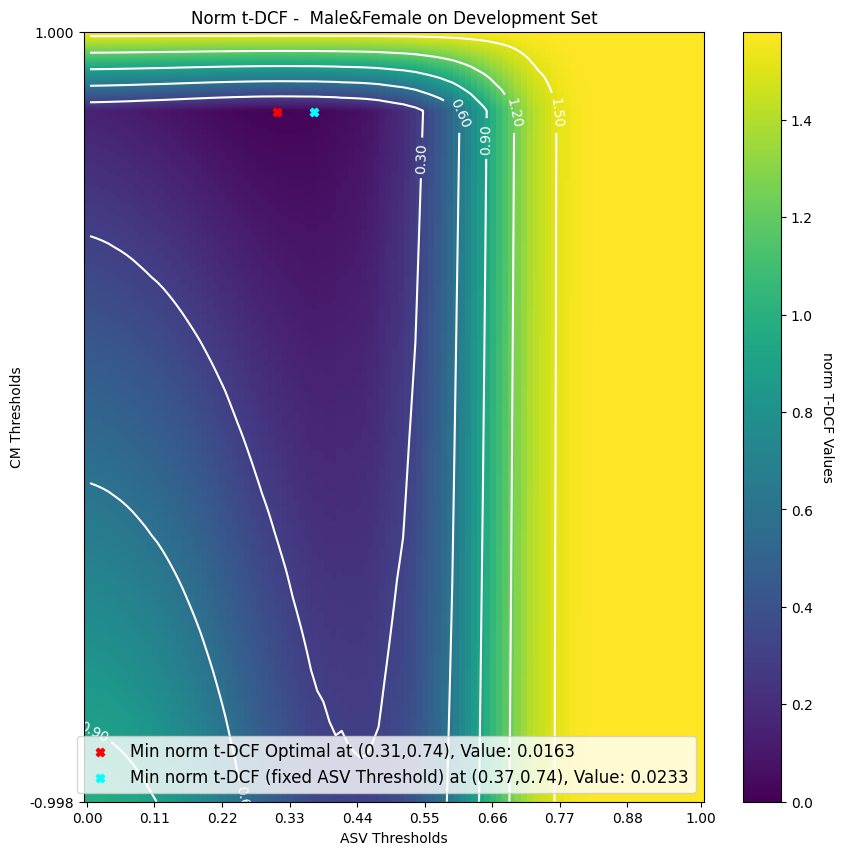

In [130]:
heatmap_norm_tdcf(list_tDCF_norm_without_gender,list_asv_score,list_CM_thresholds_without_gender, target_values = [-1,1],title ="Norm t-DCF -  Male&Female on Development Set",point_x_index = min_index[0] ,point_y_index  = min_index[1],point_x_constrained = point_x_constrained, point_y_constrained = point_y_constrained)

## Eval:

In [131]:
from sklearn.metrics.pairwise import cosine_similarity
import torchaudio
import tqdm
from ASV_utils.config_thr import pmf_both_thr_spoof_test_all

txt_file_path = "output.txt"
csv_file_path = "output.csv"
enrollment_all  = enrollment_eval_male + enrollment_eval_female
list_files = file_name_according_speaker_id_eval
data_set = Eval_dataset_all
asv_model = classifier
spoof_labels = spoof_label_eval
list_speaker_id = speaker_id_list_eval
list_asv_label = asv_label_eval

#results_eval_without_gender = inference_system_cm_asv_avg_score_without_gender(spoof_labels,list_speaker_id,list_asv_label,txt_file_path,csv_file_path,pmf_both_thr_spoof_test_all,enrollment_all, list_files, data_set, spoof_model, asv_model, device, verbose = False, verbose_txt = False,verbose_csv = False)

In [132]:

import pickle
#with open('results_eval_without_gender_avg_score_both_asv_protocol.pkl', 'wb') as f:
#    pickle.dump(results_eval_without_gender,f)


In [133]:

import pickle
file_path = "./dcf_and_tdcf\dcf_avg_score/pmf_both_tdcf/asv_protocol/results_eval_without_gender_avg_score_both_asv_protocol.pkl"
with open(file_path, 'rb') as file:
    results_eval_without_gender = pickle.load(file)


In [134]:
labels_eval_without_gender = torch.Tensor(Eval_dataset_all.is_spoofed.values).cpu().numpy().copy()
total_data = torch.Tensor(Eval_dataset_all.data_without_separation).cpu().numpy().copy()
with torch.no_grad():
    spoof_model = spoof_model.to(device)
    output = spoof_model(torch.Tensor(total_data).to(device))
    _ , score_eval_without_gender = spoof_model.loss(torch.Tensor(output).to(device),None)
    score_eval_without_gender = -1*score_eval_without_gender
    
score_eval_without_gender = score_eval_without_gender.cpu().numpy().copy()

eer_eval_without_gender, _ = my_functions.compute_eer(labels_eval_without_gender,score_eval_without_gender) # compute equal error rate


print(f"\tTest EER: ({100*eer_eval_without_gender}%)")

	Test EER: (10.210740992543693%)


In [135]:
def read_text_file(file_path):
    try:
        with open(file_path, 'r',) as file:
            lines = file.readlines()
            split_lines = [line.strip().split(' ')[0] for line in lines]
        return split_lines
    except FileNotFoundError:
        print("Error: File not found.")
        return None
    except Exception as e:
        print(f"Error: {e}")
        return None


file_path = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.male.trn.txt"
possible_speakers_male = read_text_file(file_path)

file_path = "./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.female.trn.txt"
possible_speakers_female = read_text_file(file_path)

In [136]:
from ASV_utils.tdcf_functions import compute_t_dcf
gender = 'male'

check_male =(results_eval_without_gender['speaker_id'].isin(possible_speakers_male))


bonafide_score_cm = score_eval_without_gender[(labels_eval_without_gender == 0) & (Eval_dataset_all.sex == gender)]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_eval_without_gender[(labels_eval_without_gender == 1) & (Eval_dataset_all.sex == gender)]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_eval_without_gender.loc[(results_eval_without_gender['asv_label'] == "target") & check_male]["asv_score"].values
nontarget_scores = results_eval_without_gender.loc[(results_eval_without_gender['asv_label'] == "nontarget")  & check_male]["asv_score"].values
spoof_scores = results_eval_without_gender.loc[(results_eval_without_gender['asv_label'] ==  "spoof")  & check_male]["asv_score"].values

list_asv_score = [0.384]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=2283, Nspoof=19656] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.83051 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.384
the CM thresholds is:  [-0.99685462 -0.99585462 -0.99558783 ...  0.99955177  0.99956244
  0.99958259]
the CM threshold min is: 0.9851580262184143
the tDCF_norm i

In [137]:
gender = 'female'
check_female =(results_eval_without_gender['speaker_id'].isin(possible_speakers_female))



bonafide_score_cm = score_eval_without_gender[(labels_eval_without_gender == 0) &  (Eval_dataset_all.sex == gender)]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_eval_without_gender[(labels_eval_without_gender == 1) &  (Eval_dataset_all.sex == gender)]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_eval_without_gender.loc[(results_eval_without_gender['asv_label'] == "target") & check_female]["asv_score"].values
nontarget_scores = results_eval_without_gender.loc[(results_eval_without_gender['asv_label'] == "nontarget")  & check_female]["asv_score"].values
spoof_scores = results_eval_without_gender.loc[(results_eval_without_gender['asv_label'] ==  "spoof")  & check_female]["asv_score"].values

list_asv_score = [0.384]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=5072, Nspoof=44226] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.90121 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.384
the CM thresholds is:  [-0.99741258 -0.99641258 -0.99634379 ...  0.99961841  0.99963832
  0.99964005]
the CM threshold min is: 0.9918527603149414
the tDCF_norm i

In [138]:
from ASV_utils.tdcf_functions import compute_t_dcf
gender = 'all'
bonafide_score_cm = score_eval_without_gender[labels_eval_without_gender == 0]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_eval_without_gender[labels_eval_without_gender == 1]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_eval_without_gender.loc[results_eval_without_gender['asv_label'] == "target"]["asv_score"].values
nontarget_scores = results_eval_without_gender.loc[results_eval_without_gender['asv_label'] == "nontarget"]["asv_score"].values
spoof_scores = results_eval_without_gender.loc[results_eval_without_gender['asv_label'] ==  "spoof"]["asv_score"].values

list_asv_score = [0.375,0.384]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=7355, Nspoof=63882] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.83829 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  0.375
the CM thresholds is:  [-0.99741258 -0.99641258 -0.99634379 ...  0.99961841  0.99963832
  0.99964005]
the CM threshold min is: 0.9907342791557312
the tDCF_norm i

In [139]:
results_eval_without_gender

,file_name,its_spoof,spoof_score,spoof_ground_truth,asv_score,speaker_id,find_speaker_in_enroll,asv_label,attack_type,in_cm_protocol
0,LA_E_1103494,False,-0.998118,False,0.607649,LA_0015,True,target,none,True
1,LA_E_4861467,False,-0.998306,False,0.652226,LA_0015,True,target,none,True
2,LA_E_6229989,False,-0.998424,False,0.645379,LA_0015,True,target,none,True
3,LA_E_4483232,False,-0.998880,False,0.710620,LA_0015,True,target,none,True
4,LA_E_3110493,False,-0.999037,False,0.564846,LA_0015,True,target,none,True
...,...,...,...,...,...,...,...,...,...,...
102574,LA_E_6346294,False,-0.996954,True,0.276046,LA_0020,True,spoof,A18,True
102575,LA_E_4892925,True,0.978704,True,0.260937,LA_0020,True,spoof,A19,True
102576,LA_E_4102704,False,-0.996466,True,0.218130,LA_0020,True,spoof,A17,True
102577,LA_E_4796101,True,-0.966712,True,0.287498,LA_0020,True,spoof,A18,True


In [140]:
# # Sort target scores by index and extract the corresponding filenames
# results = results_eval_without_gender
# sorted_target_scores_male_dev = results.loc[
#     (results['asv_label'] == "target"),
#     ["asv_score", "file_name","asv_label","speaker_id"]
# ].sort_index()



# # Sort nontarget scores by index and extract the corresponding filenames
# sorted_nontarget_scores_male_dev = results.loc[
#     (results['asv_label'] == "nontarget"),
#     ["asv_score", "file_name","asv_label","speaker_id"]
# ].sort_index()



# # Sort spoof scores by index and extract the corresponding filenames
# sorted_spoof_scores_male_dev = results.loc[
#     (results['asv_label'] == "spoof") ,
#     ["asv_score", "file_name","asv_label","speaker_id"]
# ].sort_index()

# # Open a file to write the output
# with open("output_scores_all_eval.txt", "w") as file:
#     # Write for target scores
#     for index, row in sorted_target_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id']
#         utterance_id = row['file_name']  # Assuming file_name contains the utterance_id
#         score = row['asv_score']
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")

#     # Write for nontarget scores
#     for index, row in sorted_nontarget_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id']
#         utterance_id = row['file_name']
#         score = row['asv_score']
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")

#     # Write for spoof scores
#     for index, row in sorted_spoof_scores_male_dev.iterrows():
#         speaker_id = row['speaker_id']
#         utterance_id = row['file_name']
#         score = row['asv_score']
#         trial_type = row['asv_label']
#         file.write(f"{speaker_id} {utterance_id} {score:.4f} {trial_type}\n")


In [141]:
from ASV_utils.tdcf_functions import compute_t_dcf
gender = 'all'
bonafide_score_cm = score_eval_without_gender[labels_eval_without_gender == 0]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_eval_without_gender[labels_eval_without_gender == 1]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_eval_without_gender.loc[results_eval_without_gender['asv_label'] == "target"]["asv_score"].values
nontarget_scores = results_eval_without_gender.loc[results_eval_without_gender['asv_label'] == "nontarget"]["asv_score"].values
spoof_scores = results_eval_without_gender.loc[results_eval_without_gender['asv_label'] ==  "spoof"]["asv_score"].values

list_asv_score = [0.375,0.384]
type = 'constrained_ver2'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained_ver2
t-DCF evaluation from [Nbona=7355, Nspoof=63882] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa          = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss        =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_spoof    = 10.00000 (Cost of CM falsely passing a spoof to ASV system)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
the asv threshold is from eer on asv development set  0.375
the CM thresholds is:  [-0.99741258 -0.99641258 -0.99634379 ...  0.99961841  0.99963832
  0.99964005]
the CM threshold min is: 0.9907342791557312
the tDCF_norm is: [1.         0.99998466 0.99996932 ... 2.80055145 2.80092958 2.80130772]
the min tDCF_norm is: 0.3299275338533343
the tDCF is: [0.33573605 0.3357

In [142]:
from ASV_utils.tdcf_functions import compute_t_dcf
gender = 'all'
bonafide_score_cm = score_eval_without_gender[labels_eval_without_gender == 0]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_eval_without_gender[labels_eval_without_gender == 1]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

target_scores = results_eval_without_gender.loc[results_eval_without_gender['asv_label'] == "target"]["asv_score"].values
nontarget_scores = results_eval_without_gender.loc[results_eval_without_gender['asv_label'] == "nontarget"]["asv_score"].values
spoof_scores = results_eval_without_gender.loc[results_eval_without_gender['asv_label'] ==  "spoof"]["asv_score"].values

list_asv_score = np.arange(0, 1.01, 0.01)
type = 'unconstrained'

point_y_constrained = np.argmin(list_tDCF_norm_without_gender[1])
point_x_constrained = (np.abs(np.array(list_asv_score)-[0.384])).argmin()

list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,target_scores,nontarget_scores,spoof_scores,list_asv_score,type)

tDCF_norm_without_gender = np.array(list_tDCF_norm_without_gender)

CM_thresholds_without_gender = np.array(list_CM_thresholds_without_gender)

min_index = np.unravel_index(np.nanargmin(tDCF_norm_without_gender), tDCF_norm_without_gender.shape)

# Print the results
print("tDCF - Minimum value:", tDCF_norm_without_gender[min_index])
print("Index of minimum value:", min_index)
print("The min asv score:", list_asv_score[min_index[0]])
print("The min CM thersholds:",CM_thresholds_without_gender[min_index])

The t-DCF evaluation type is: unconstrained
t-DCF evaluation from [Nbona=7355, Nspoof=63882] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa          = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss        =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_spoof    = 10.00000 (Cost of CM falsely passing a spoof to ASV system)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
the asv threshold is from eer on asv development set  0.0
the CM thresholds is:  [-0.99741258 -0.99641258 -0.99634379 ...  0.99961841  0.99963832
  0.99964005]
the CM threshold min is: 0.9925401210784912
the tDCF_norm is: [0.98342989 0.98341685 0.98340381 ... 1.58028334 1.5804778  1.58067227]
the min tDCF_norm is: 0.3671703614448578
the tDCF is: [0.58514079 0.58513303 

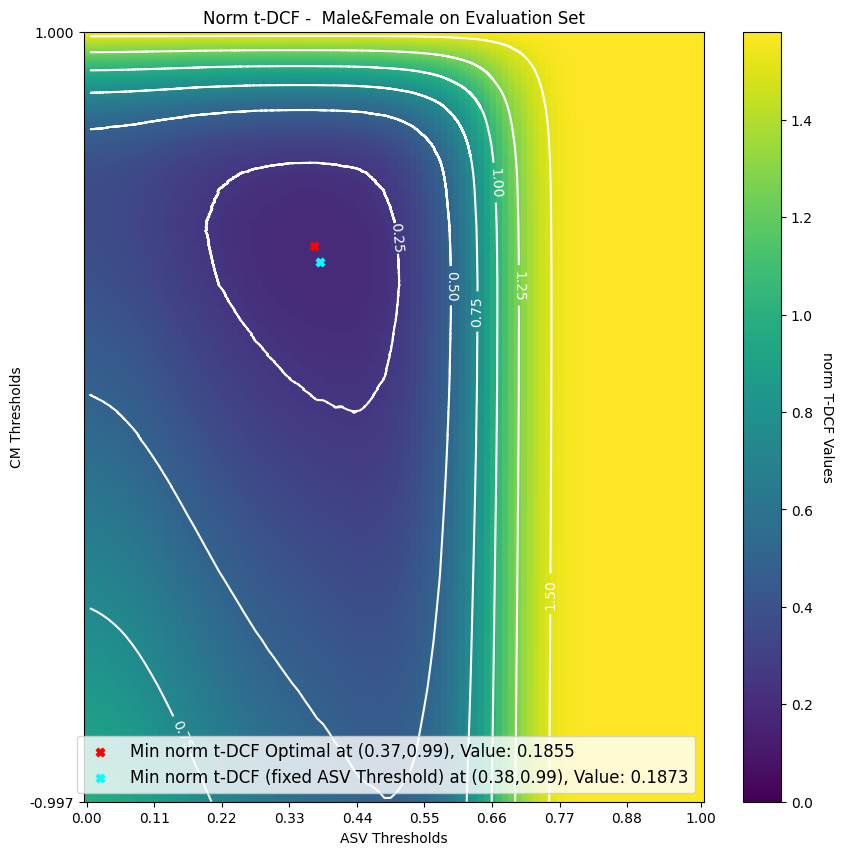

In [143]:
heatmap_norm_tdcf(list_tDCF_norm_without_gender,list_asv_score,list_CM_thresholds_without_gender, target_values = [-1,1],title ="Norm t-DCF -  Male&Female on Evaluation Set",point_x_index = min_index[0] ,point_y_index  = min_index[1],point_x_constrained = point_x_constrained, point_y_constrained = point_y_constrained)

In [150]:
# from ASV_utils.config_thr import pmf_both_thr_spoof_test_all
# list_asv_score = [0.375,0.384]
# CM_thr = pmf_both_thr_spoof_test_all
# ASV_thr =  list_asv_score[0]
# spoof_score_cm_all_eval = results_eval_without_gender['spoof_score']
# think_is_geninue = spoof_score_cm_all_eval.loc[spoof_score_cm_all_eval<CM_thr] 
# print(results_eval_without_gender.loc[think_is_geninue.index]['asv_label'].value_counts())
# print("--------------------------------------------------------")
# to_asv = results_eval_without_gender.loc[(think_is_geninue.index)]
# print(to_asv.loc[to_asv['asv_score']>ASV_thr]['asv_label'].value_counts())
# print("--------------------------------------------------------")
# ## all the files inside the system cm -> inside -> asv
# indexes = []
# path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) 
# for file in results_eval_without_gender.loc[think_is_geninue.index]['file_name'].values:
#     index = path_name.str.contains(file)
#     indexes.append(index.loc[index==True].index[0])
# print(Eval_dataset_all.attack_logical[indexes].value_counts())
# print("--------------------------------------------------------")
# ## all the files inside the system cm -> asv -> inside
# indexes = []
# path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) # Get the path names of the data set
# for file in to_asv.loc[to_asv['asv_score']>ASV_thr]['file_name'].values:
#     index = path_name.str.contains(file)
#     indexes.append(index.loc[index==True].index[0])
# print(Eval_dataset_all.attack_logical[indexes].value_counts())
# print("--------------------------------------------------------")

In [ ]:
# CM_thr = pmf_both_thr_spoof_test_all
# ASV_thr =  list_asv_score[1]
# spoof_score_cm_all_eval = results_eval_without_gender['spoof_score']
# think_is_geninue = spoof_score_cm_all_eval.loc[spoof_score_cm_all_eval<CM_thr] 
# print(results_eval_without_gender.loc[think_is_geninue.index]['asv_label'].value_counts())
# print("--------------------------------------------------------")
# to_asv = results_eval_without_gender.loc[(think_is_geninue.index)]
# print(to_asv.loc[to_asv['asv_score']>ASV_thr]['asv_label'].value_counts())
# print("--------------------------------------------------------")
# ## all the files inside the system cm -> inside -> asv
# indexes = []
# path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) 
# for file in results_eval_without_gender.loc[think_is_geninue.index]['file_name'].values:
#     index = path_name.str.contains(file)
#     indexes.append(index.loc[index==True].index[0])
# print(Eval_dataset_all.attack_logical[indexes].value_counts())
# print("--------------------------------------------------------")
# ## all the files inside the system cm -> asv -> inside
# indexes = []
# path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) # Get the path names of the data set
# for file in to_asv.loc[to_asv['asv_score']>ASV_thr]['file_name'].values:
#     index = path_name.str.contains(file)
#     indexes.append(index.loc[index==True].index[0])
# print(Eval_dataset_all.attack_logical[indexes].value_counts())
# print("--------------------------------------------------------")

asv_label
nontarget    31805
spoof        14004
target        5172
Name: count, dtype: int64
--------------------------------------------------------
asv_label
spoof        7601
target       5138
nontarget     258
Name: count, dtype: int64
--------------------------------------------------------
[none]    36977
[A17]      3914
[A15]      3551
[A18]      2324
[A10]      2144
[A14]      1262
[A11]       789
[A13]        19
[A12]         1
Name: count, dtype: int64
--------------------------------------------------------
[none]    5396
[A15]     3507
[A10]     2033
[A14]     1144
[A11]      743
[A18]       91
[A17]       74
[A13]        8
[A12]        1
Name: count, dtype: int64
--------------------------------------------------------


In [ ]:
# list_asv_score = np.arange(0, 1.01, 0.01)
# CM_thr = 1-CM_thresholds_without_gender[min_index]
# ASV_thr = list_asv_score[min_index[0]]
# spoof_score_cm_all_eval = results_eval_without_gender['spoof_score']
# think_is_geninue = spoof_score_cm_all_eval.loc[spoof_score_cm_all_eval<CM_thr] 
# print(results_eval_without_gender.loc[think_is_geninue.index]['asv_label'].value_counts())
# print("--------------------------------------------------------")
# to_asv = results_eval_without_gender.loc[(think_is_geninue.index)]
# print(to_asv.loc[to_asv['asv_score']>ASV_thr]['asv_label'].value_counts())
# print("--------------------------------------------------------")
# ## all the files inside the system cm -> inside -> asv
# indexes = []
# path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) 
# for file in results_eval_without_gender.loc[think_is_geninue.index]['file_name'].values:
#     index = path_name.str.contains(file)
#     indexes.append(index.loc[index==True].index[0])
# print(Eval_dataset_all.attack_logical[indexes].value_counts())
# print("--------------------------------------------------------")
# ## all the files inside the system cm -> asv -> inside
# indexes = []
# path_name = pd.Series(np.concatenate(Eval_dataset_all.name.values)) # Get the path names of the data set
# for file in to_asv.loc[to_asv['asv_score']>ASV_thr]['file_name'].values:
#     index = path_name.str.contains(file)
#     indexes.append(index.loc[index==True].index[0])
# print(Eval_dataset_all.attack_logical[indexes].value_counts())
# print("--------------------------------------------------------")

asv_label
nontarget    33305
spoof        33283
target        5368
Name: count, dtype: int64
--------------------------------------------------------
asv_label
spoof        21922
target        5341
nontarget      376
Name: count, dtype: int64
--------------------------------------------------------
[none]    38673
[A15]      4905
[A18]      4838
[A10]      4793
[A17]      4793
[A14]      4634
[A11]      4577
[A13]      3693
[A12]       547
[A09]       377
[A19]        99
[A08]        25
[A16]         1
[A07]         1
Name: count, dtype: int64
--------------------------------------------------------
[none]    5717
[A15]     4862
[A10]     4641
[A14]     4484
[A11]     4414
[A13]     2621
[A12]      468
[A18]      295
[A17]      109
[A19]       13
[A08]       11
[A09]        2
[A16]        1
[A07]        1
Name: count, dtype: int64
--------------------------------------------------------


### read from ASVspoof2019 scores:

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import utils.eval_metrics as eval_metrics 
def read_txt_ASV2019_scores(file_path):
    is_spoofed = []
    label = []
    score = []
    with open(file_path, 'r') as file:
        for line in file:
            parts = line.strip().split(' ')
            if len(parts) != 3:
                raise Exception("The line in the file is not in the right format")
            is_spoofed.append(parts[0])
            label.append(parts[1])
            score.append(parts[2])
            
    return pd.Series(is_spoofed), pd.Series(label), pd.Series(score)

### Dev

In [146]:

file_path ="./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.gi.trl.scores.txt"
 
ASV2019_attack_type ,ASV2019_label,ASV2019_scores  = read_txt_ASV2019_scores(file_path)

bonafide_score_cm = score_dev_without_gender[labels_dev_without_gender == 0]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_dev_without_gender[labels_dev_without_gender == 1]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

ASV2019_target_scores = ASV2019_scores.loc[ASV2019_label == "target"].astype(float)
ASV2019_nontarget_scores = ASV2019_scores.loc[ASV2019_label == "nontarget"].astype(float)
ASV2019_spoof_scores = ASV2019_scores.loc[ASV2019_label == "spoof"].astype(float)

ASV2019_eer_scores_dev,ASV2019_thr_eer_scores_dev,_,_ = eval_metrics.compute_eer(ASV2019_target_scores.values.astype(float),ASV2019_nontarget_scores.values.astype(float))

list_asv_score = [ASV2019_thr_eer_scores_dev]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,ASV2019_target_scores,ASV2019_nontarget_scores,ASV2019_spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=2548, Nspoof=22296] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.40799 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  -3.548998
the CM thresholds is:  [-0.99801869 -0.99701869 -0.99699306 ...  0.99958646  0.9996103
  0.99964386]
the CM threshold min is: 0.7436689138412476
the tDCF_nor

In [147]:

file_path ="./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.gi.trl.scores.txt"
 
ASV2019_attack_type ,ASV2019_label,ASV2019_scores  = read_txt_ASV2019_scores(file_path)

bonafide_score_cm = score_dev_without_gender[labels_dev_without_gender == 0]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_dev_without_gender[labels_dev_without_gender == 1]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

ASV2019_target_scores = ASV2019_scores.loc[ASV2019_label == "target"].astype(float)
ASV2019_nontarget_scores = ASV2019_scores.loc[ASV2019_label == "nontarget"].astype(float)
ASV2019_spoof_scores = ASV2019_scores.loc[ASV2019_label == "spoof"].astype(float)

ASV2019_eer_scores_dev,ASV2019_thr_eer_scores_dev,_,_ = eval_metrics.compute_eer(ASV2019_target_scores.values.astype(float),ASV2019_nontarget_scores.values.astype(float))

list_asv_score = [ASV2019_thr_eer_scores_dev]
type = 'constrained_ver2'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,ASV2019_target_scores,ASV2019_nontarget_scores,ASV2019_spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained_ver2
t-DCF evaluation from [Nbona=2548, Nspoof=22296] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa          = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss        =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_spoof    = 10.00000 (Cost of CM falsely passing a spoof to ASV system)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
the asv threshold is from eer on asv development set  -3.548998
the CM thresholds is:  [-0.99801869 -0.99701869 -0.99699306 ...  0.99958646  0.9996103
  0.99964386]
the CM threshold min is: 0.7436689138412476
the tDCF_norm is: [1.         0.99995793 0.99991586 ... 2.31888443 2.31977087 2.3206573 ]
the min tDCF_norm is: 0.06358302551716043
the tDCF is: [0.40527311 0.

### Eval

In [148]:
file_path ="./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.gi.trl.scores.txt"
 
ASV2019_attack_type ,ASV2019_label,ASV2019_scores  = read_txt_ASV2019_scores(file_path)

bonafide_score_cm = score_eval_without_gender[labels_eval_without_gender == 0]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_eval_without_gender[labels_eval_without_gender == 1]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

ASV2019_target_scores = ASV2019_scores.loc[ASV2019_label == "target"].astype(float)
ASV2019_nontarget_scores = ASV2019_scores.loc[ASV2019_label == "nontarget"].astype(float)
ASV2019_spoof_scores = ASV2019_scores.loc[ASV2019_label == "spoof"].astype(float)

ASV2019_eer_scores_eval,ASV2019_thr_eer_scores_eval,_,_ = eval_metrics.compute_eer(ASV2019_target_scores.values.astype(float),ASV2019_nontarget_scores.values.astype(float))


list_asv_score = [ASV2019_thr_eer_scores_dev,ASV2019_thr_eer_scores_eval]
type = 'constrained'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,ASV2019_target_scores,ASV2019_nontarget_scores,ASV2019_spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained
t-DCF evaluation from [Nbona=7355, Nspoof=63882] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa_asv      = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss_asv    =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_cm       = 10.00000 (Cost of CM falsely passing a spoof to ASV system)
   Cmiss_cm     =  1.00000 (Cost of CM falsely blocking target utterance which never reaches ASV)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
   tDCF_norm(s) =  2.43442 x Pmiss_cm(s) + Pfa_cm(s)

the asv threshold is from eer on asv development set  -3.548998
the CM thresholds is:  [-0.99741258 -0.99641258 -0.99634379 ...  0.99961841  0.99963832
  0.99964005]
the CM threshold min is: 0.9918527603149414
the tDCF_no

In [149]:
file_path ="./ECAPA_TDNN/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.gi.trl.scores.txt"
 
ASV2019_attack_type ,ASV2019_label,ASV2019_scores  = read_txt_ASV2019_scores(file_path)

bonafide_score_cm = score_eval_without_gender[labels_eval_without_gender == 0]
bonafide_score_cm = -1*bonafide_score_cm

spoof_score_cm = score_eval_without_gender[labels_eval_without_gender == 1]
spoof_score_cm = -1*spoof_score_cm

Prior_spoof = 0.05

ASV2019_target_scores = ASV2019_scores.loc[ASV2019_label == "target"].astype(float)
ASV2019_nontarget_scores = ASV2019_scores.loc[ASV2019_label == "nontarget"].astype(float)
ASV2019_spoof_scores = ASV2019_scores.loc[ASV2019_label == "spoof"].astype(float)

ASV2019_eer_scores_eval,ASV2019_thr_eer_scores_eval,_,_ = eval_metrics.compute_eer(ASV2019_target_scores.values.astype(float),ASV2019_nontarget_scores.values.astype(float))


list_asv_score = [ASV2019_thr_eer_scores_dev,ASV2019_thr_eer_scores_eval]
type = 'constrained_ver2'
list_tDCF_norm_without_gender ,list_CM_thresholds_without_gender,list_tDCF_without_gender  = compute_t_dcf(bonafide_score_cm,spoof_score_cm,Prior_spoof,ASV2019_target_scores,ASV2019_nontarget_scores,ASV2019_spoof_scores,list_asv_score,type)

The t-DCF evaluation type is: constrained_ver2
t-DCF evaluation from [Nbona=7355, Nspoof=63882] trials

t-DCF MODEL
   Ptar         =  0.94050 (Prior probability of target user)
   Pnon         =  0.00950 (Prior probability of nontarget user)
   Pspoof       =  0.05000 (Prior probability of spoofing attack)
   Cfa          = 10.00000 (Cost of ASV falsely accepting a nontarget)
   Cmiss        =  1.00000 (Cost of ASV falsely rejecting target speaker)
   Cfa_spoof    = 10.00000 (Cost of CM falsely passing a spoof to ASV system)

   Implied normalized t-DCF function (depends on t-DCF parameters and ASV errors), s=CM threshold)
the asv threshold is from eer on asv development set  -3.548998
the CM thresholds is:  [-0.99741258 -0.99641258 -0.99634379 ...  0.99961841  0.99963832
  0.99964005]
the CM threshold min is: 0.9918527603149414
the tDCF_norm is: [1.         0.99998569 0.99997138 ... 2.31047232 2.31077484 2.31107737]
the min tDCF_norm is: 0.35747076220669005
the tDCF is: [0.40695306 0